## Import relevant libraries and project relative paths

In [13]:
from semopy import Model, calc_stats, semplot
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import pandas as pd
import numpy as np
import seaborn as sns
from semopy.inspector import inspect

In [14]:
from pathlib import Path
import sys

# Find project root (where paths.py lives)
ROOT = Path.cwd().resolve()
while not (ROOT / "paths.py").exists():
    ROOT = ROOT.parent

# Make paths.py importable
sys.path.insert(0, str(ROOT))

# import relative paths
from paths import PROCESSED_DATA, OUTPUT_DIR, FIGURES_REPORTS

## Import data

In [15]:
df = pd.read_csv(PROCESSED_DATA/"Welzijnsmonitor2025_processed.csv", sep=";",encoding='utf-8-sig')

## Raw data descriptive statistics
Save basic data descriptive statistics

In [16]:
df.describe().to_csv(OUTPUT_DIR/"data_description.csv")

Plot distribution of the observed variables

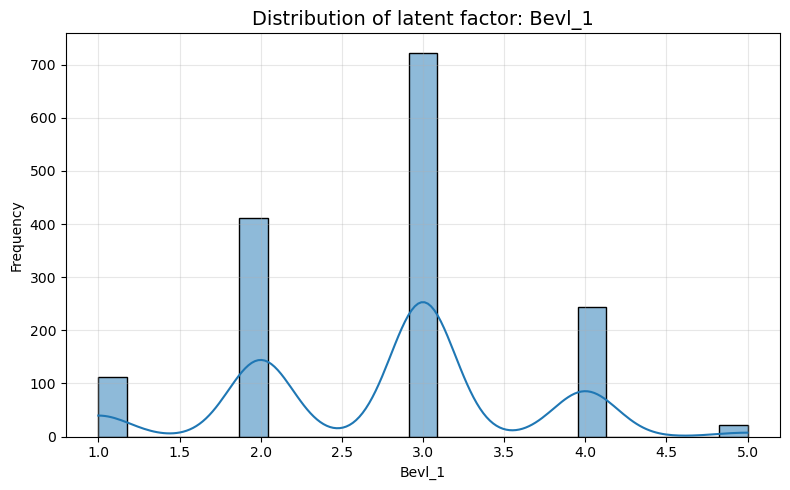

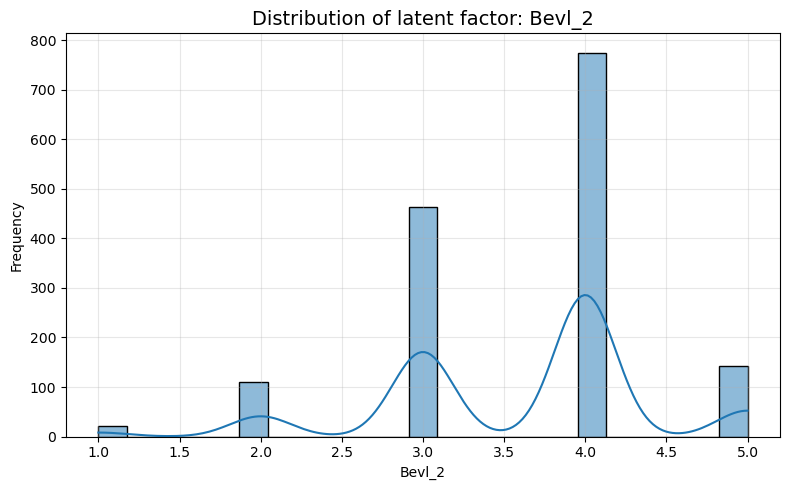

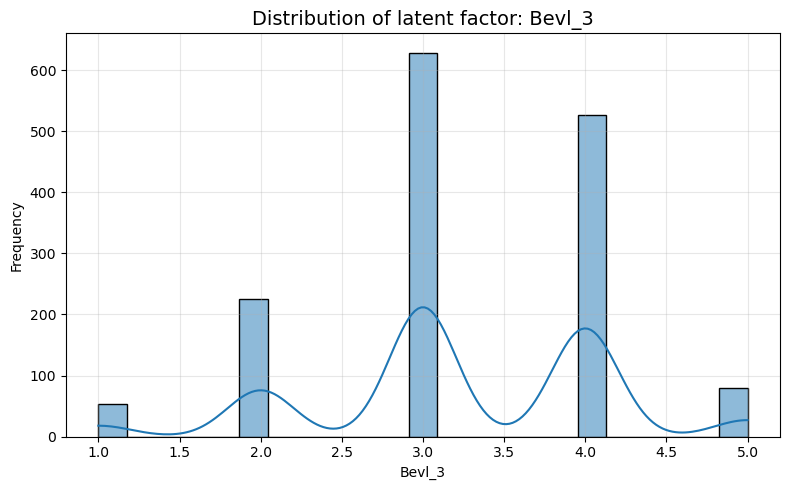

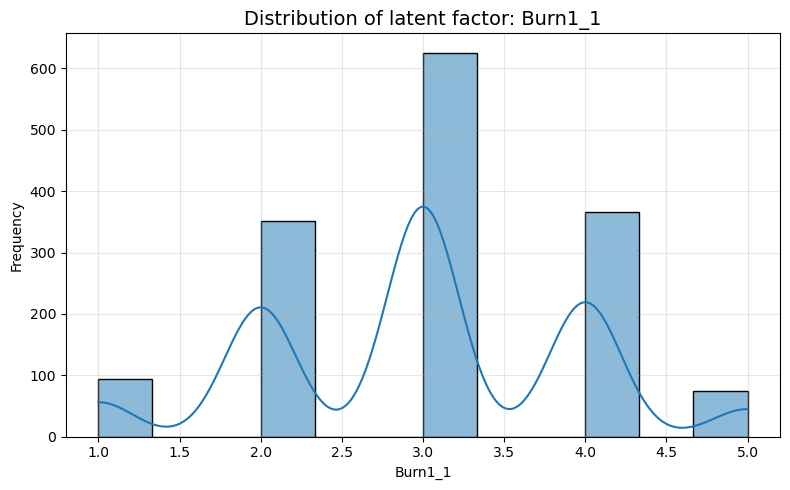

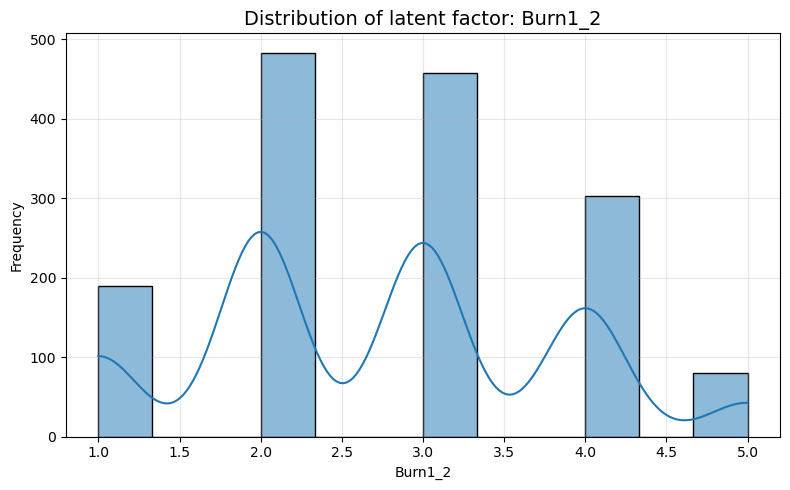

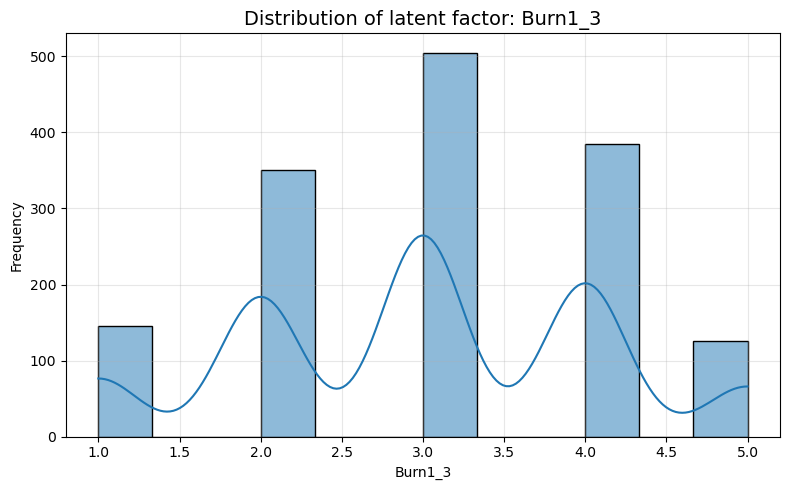

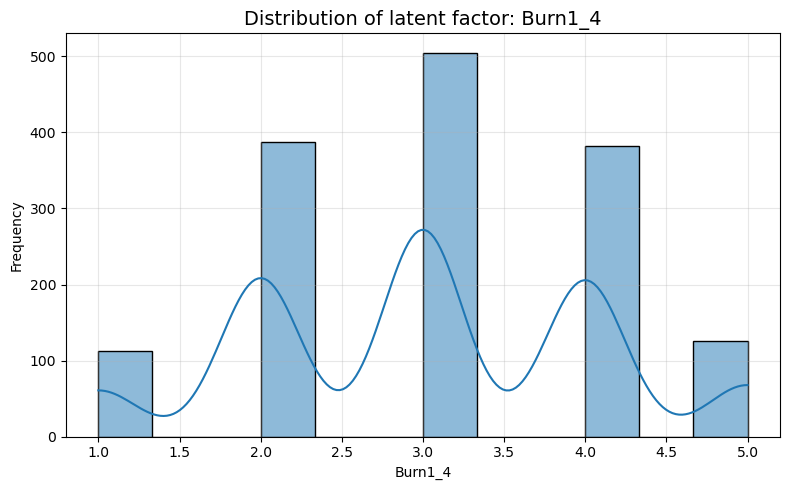

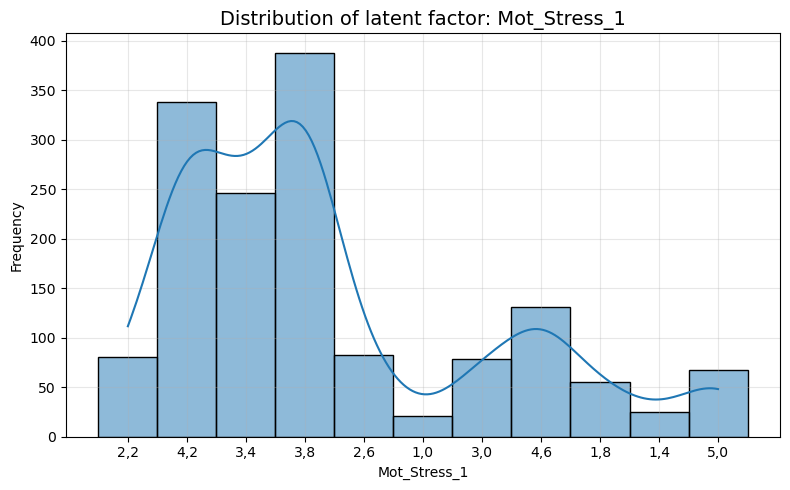

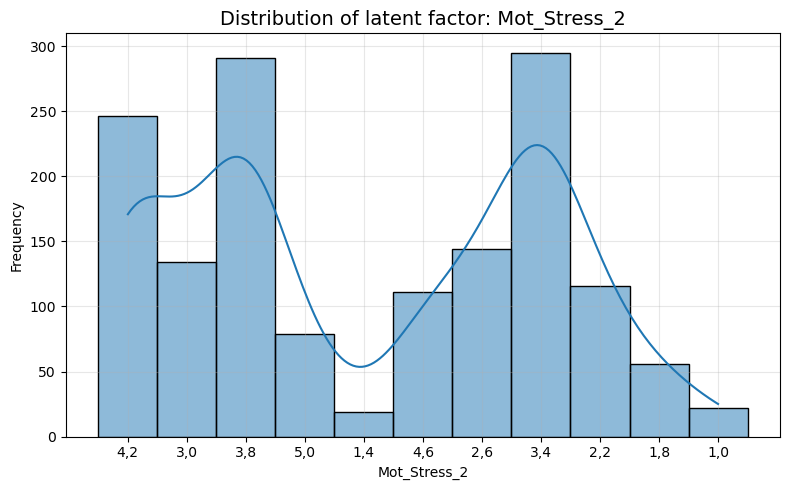

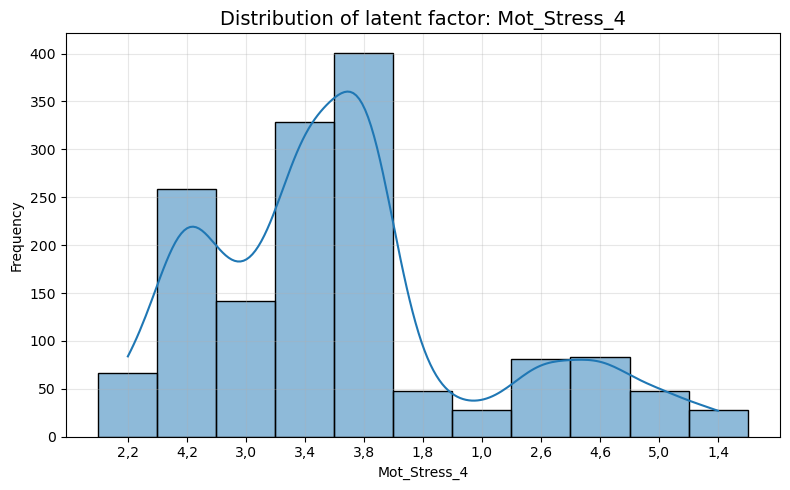

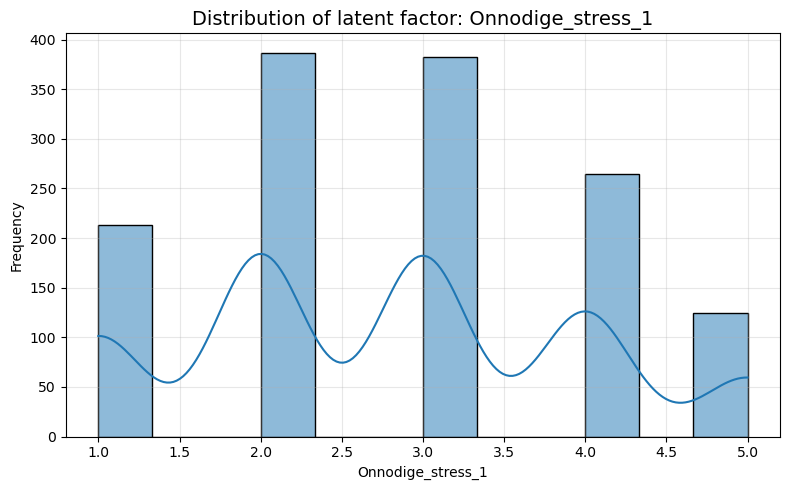

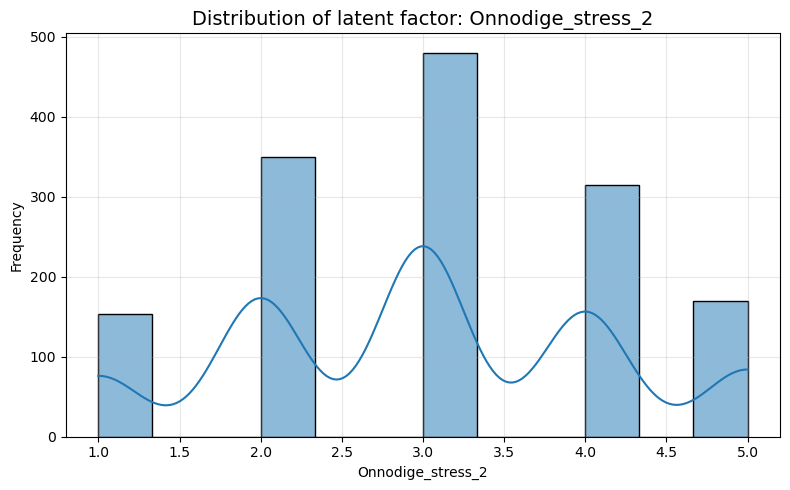

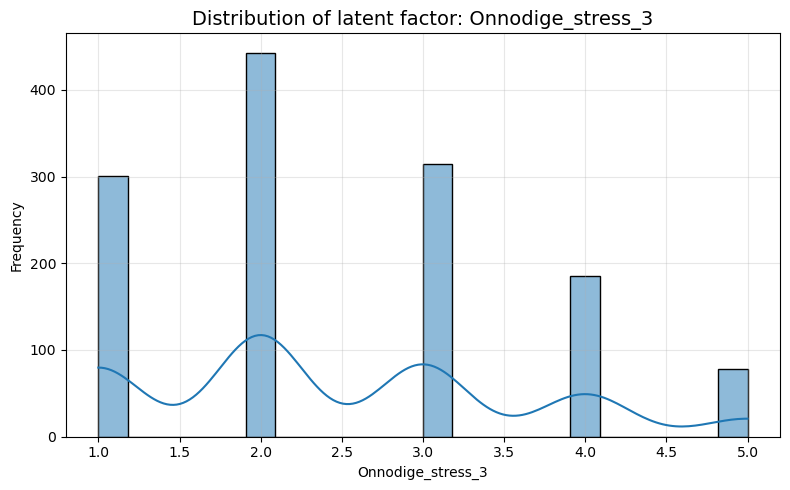

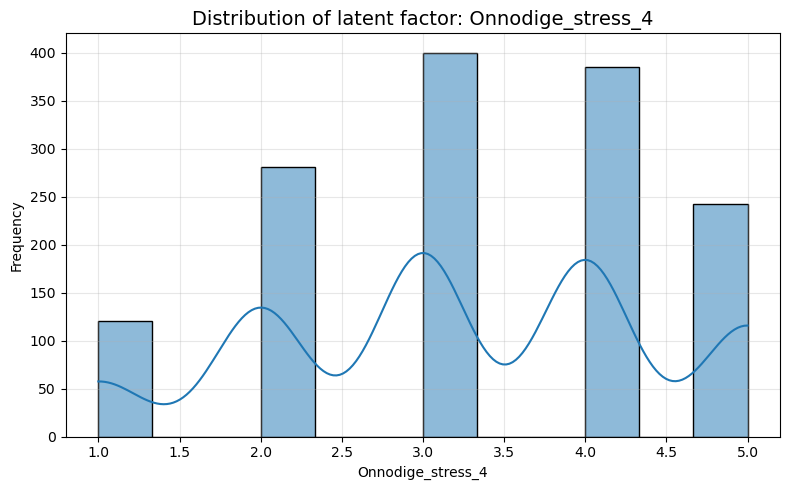

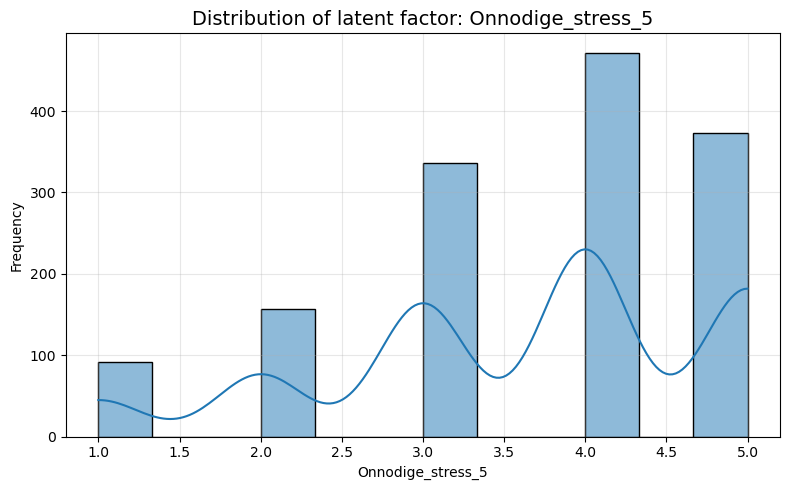

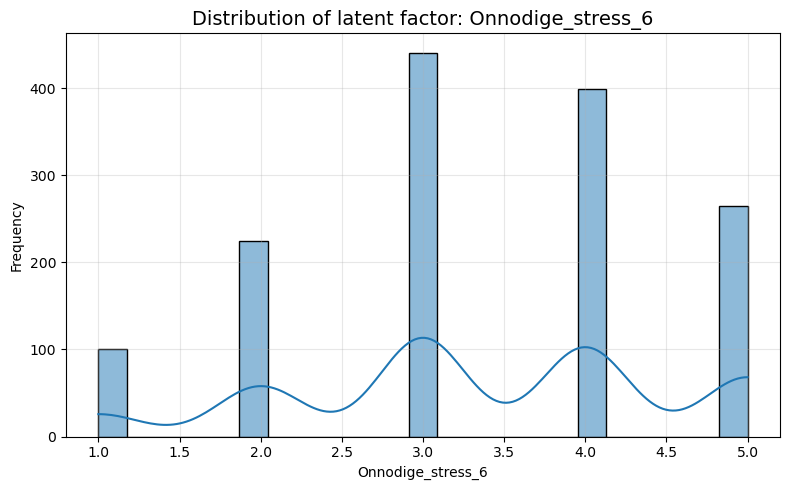

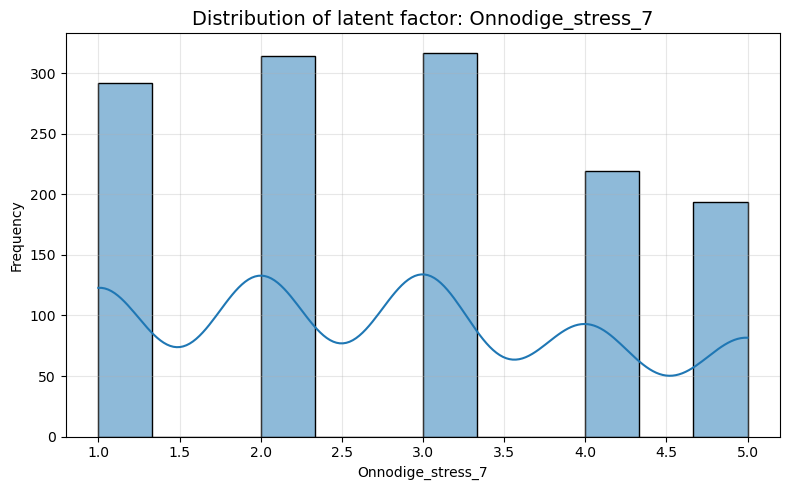

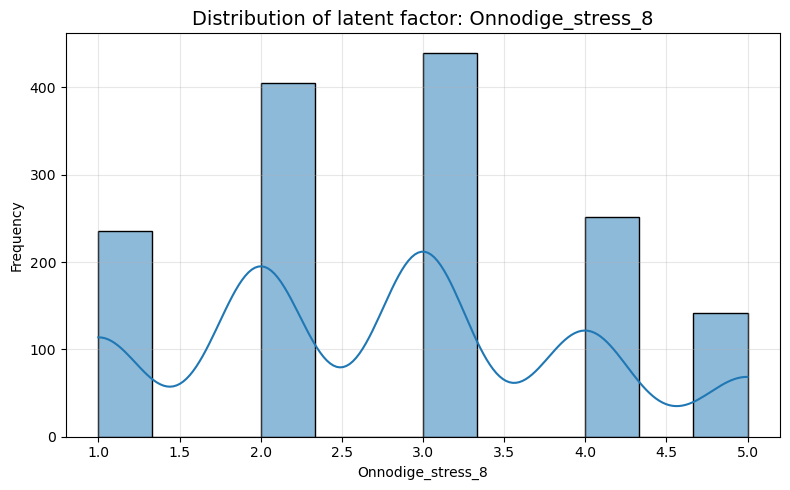

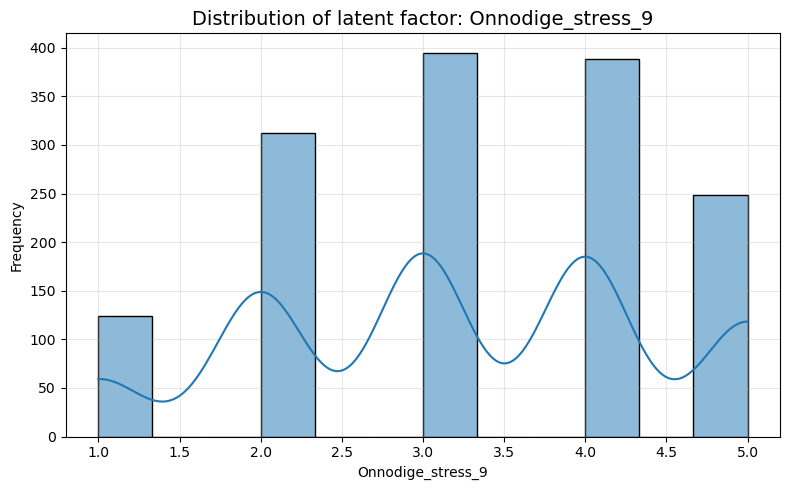

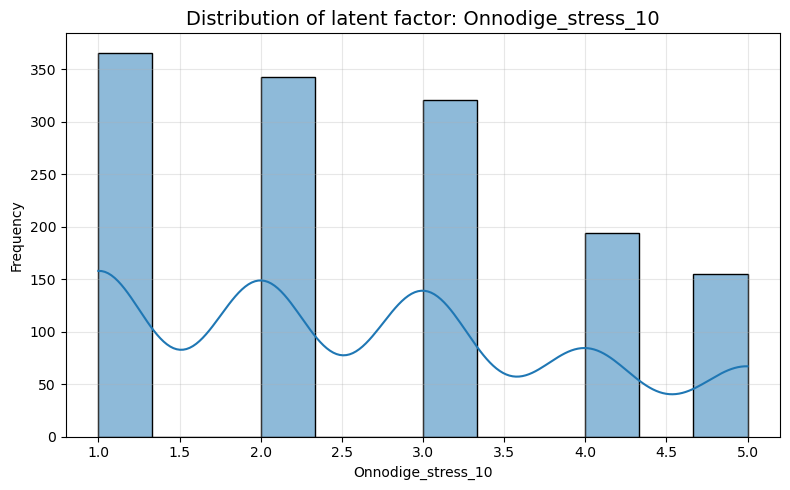

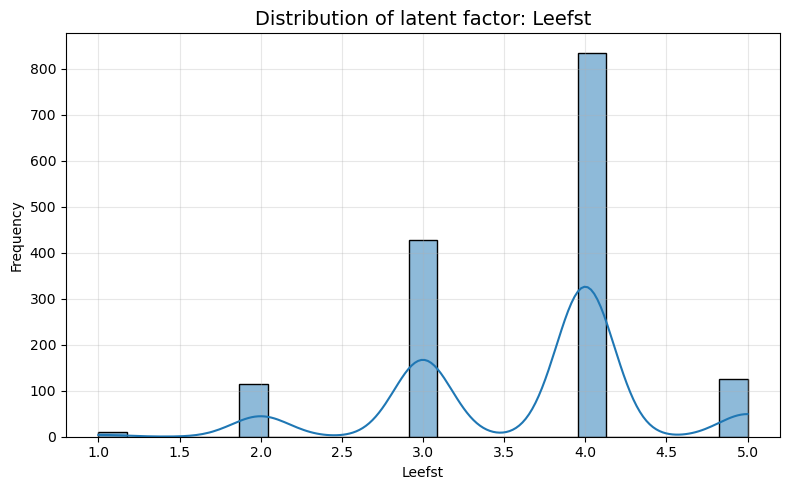

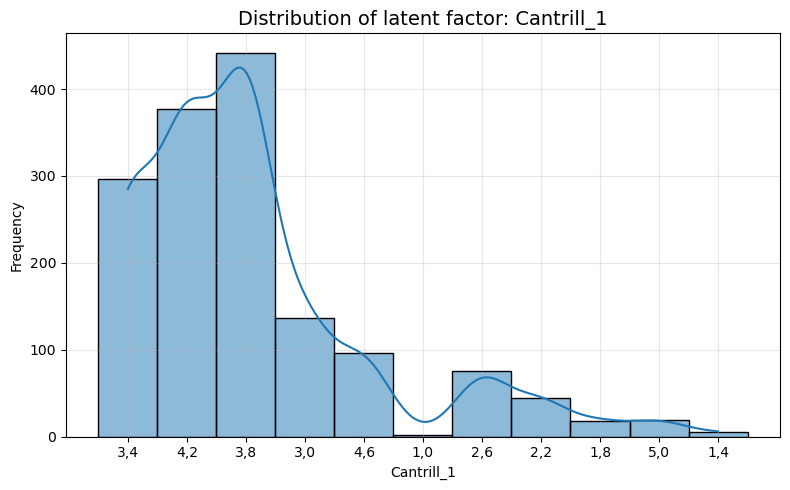

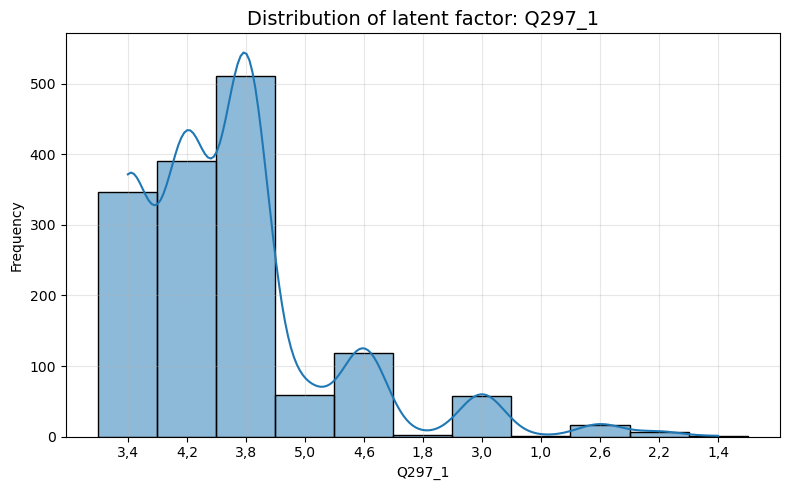

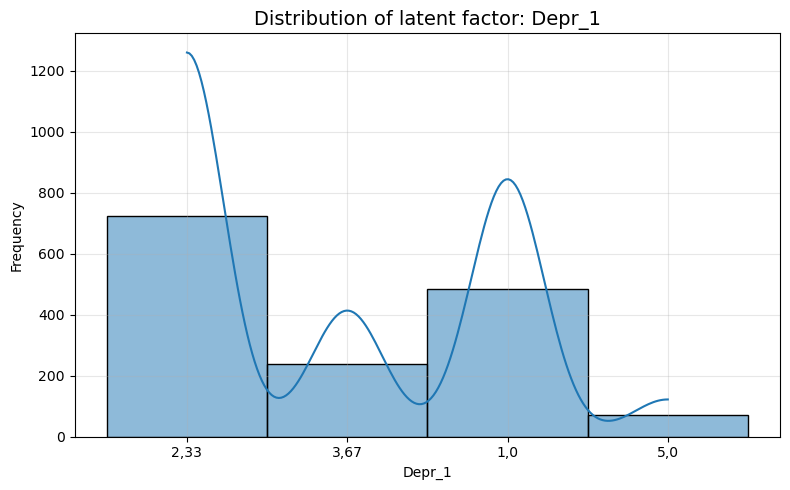

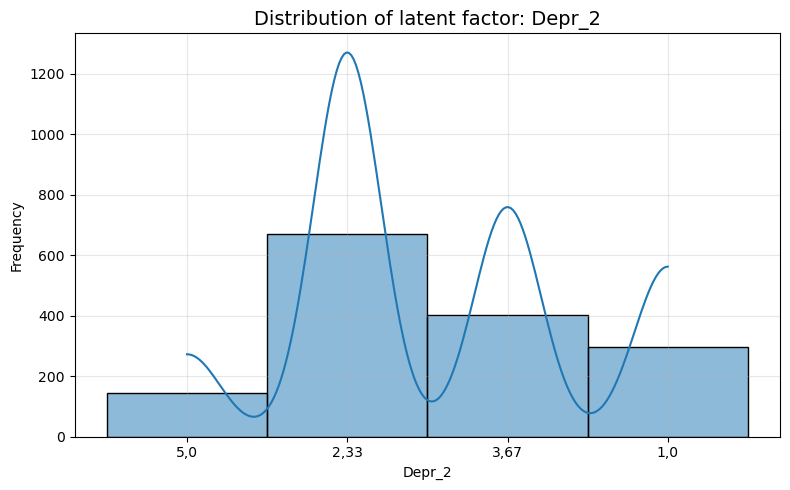

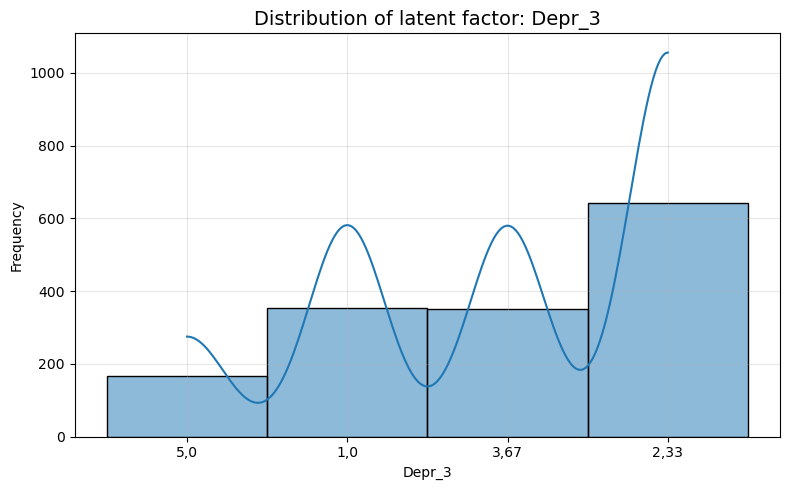

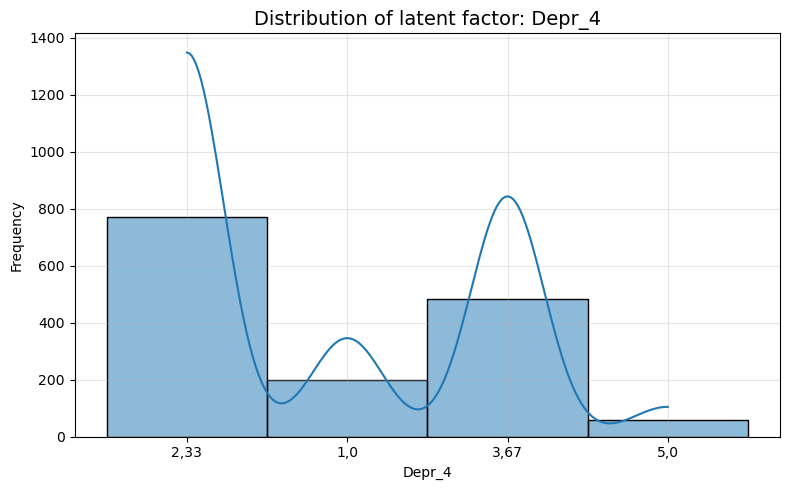

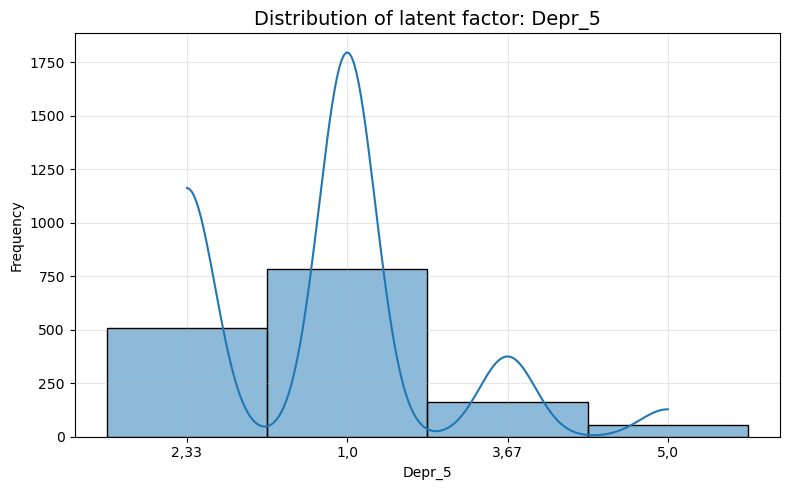

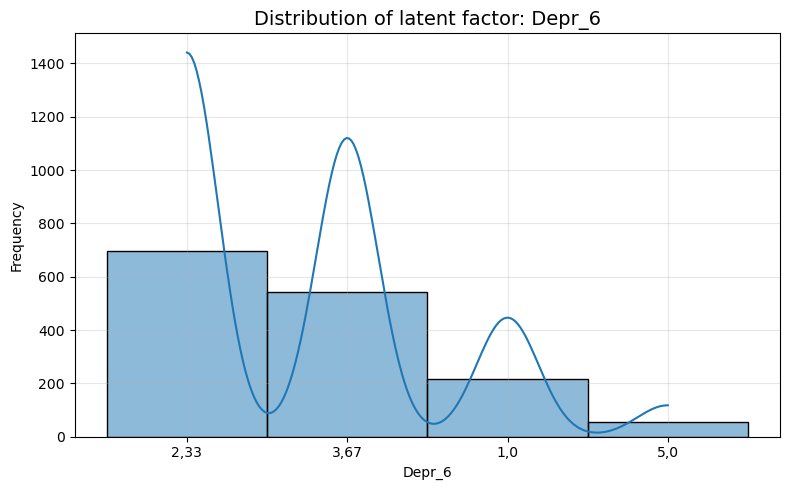

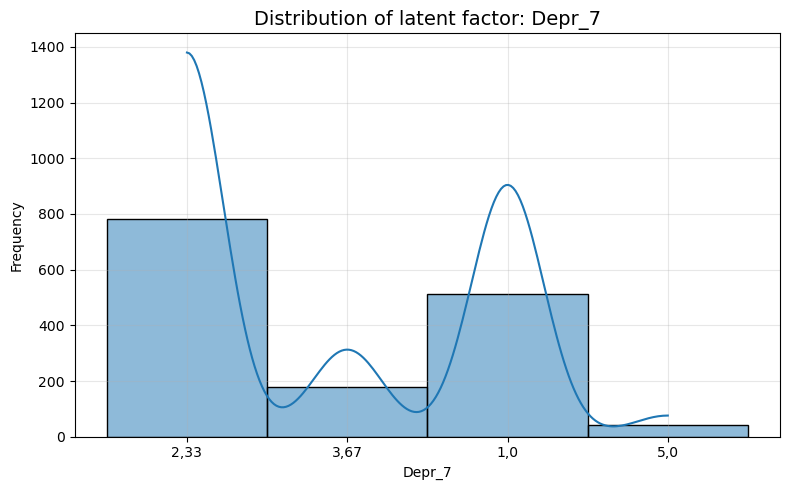

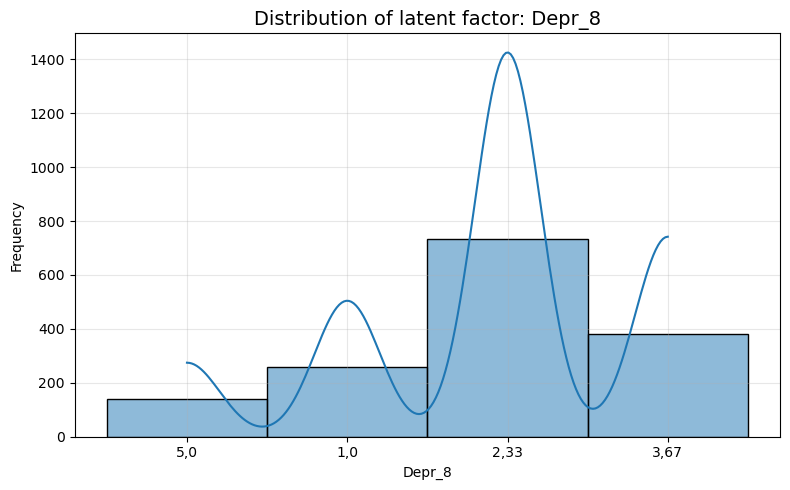

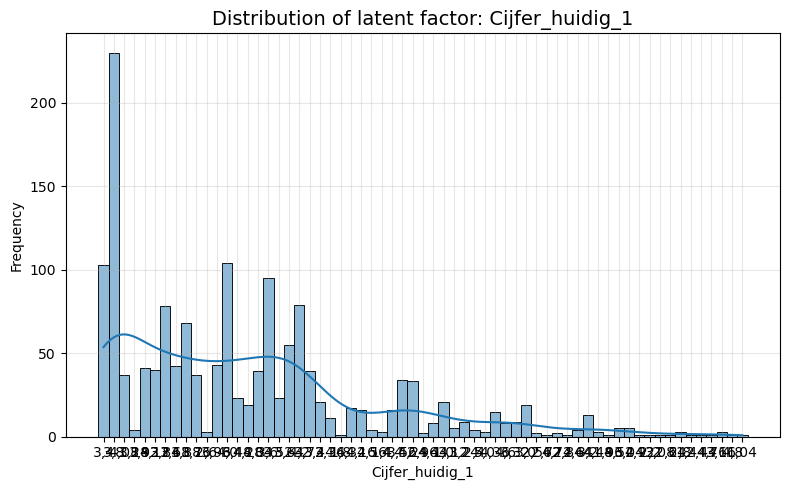

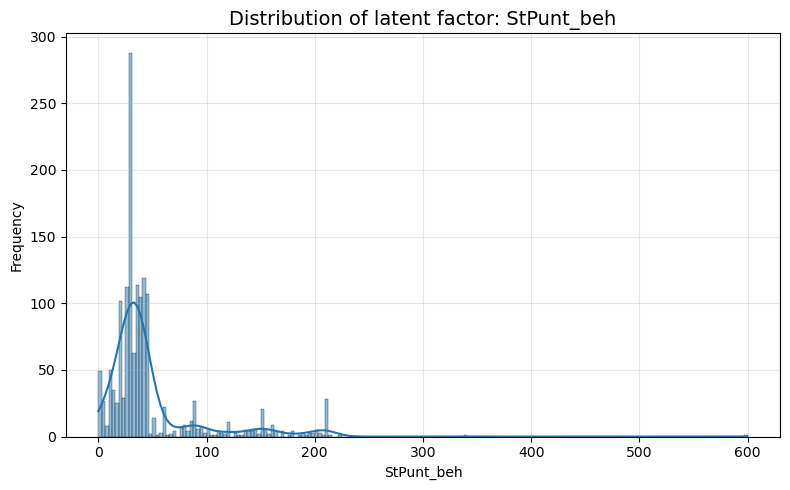

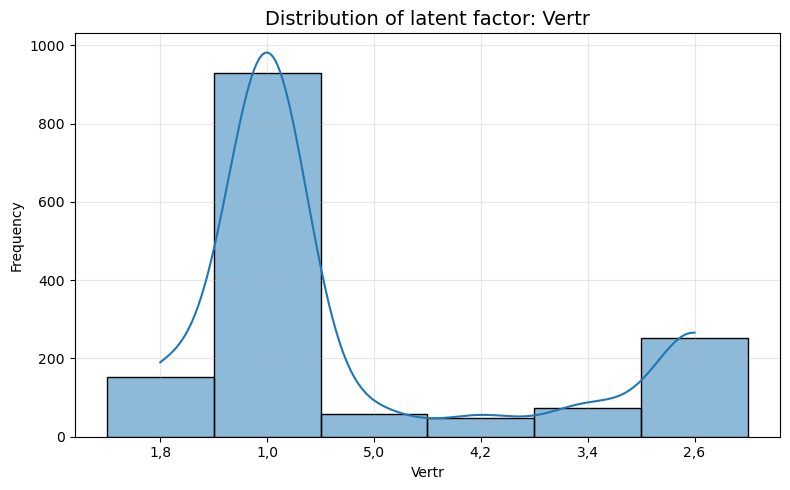

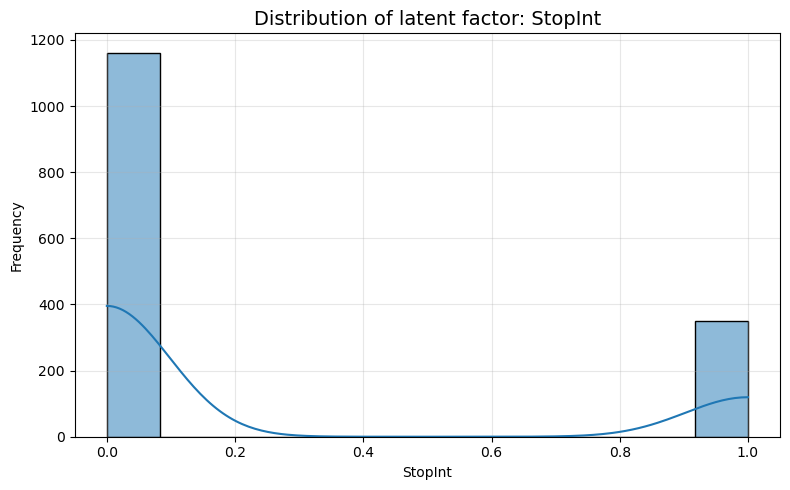

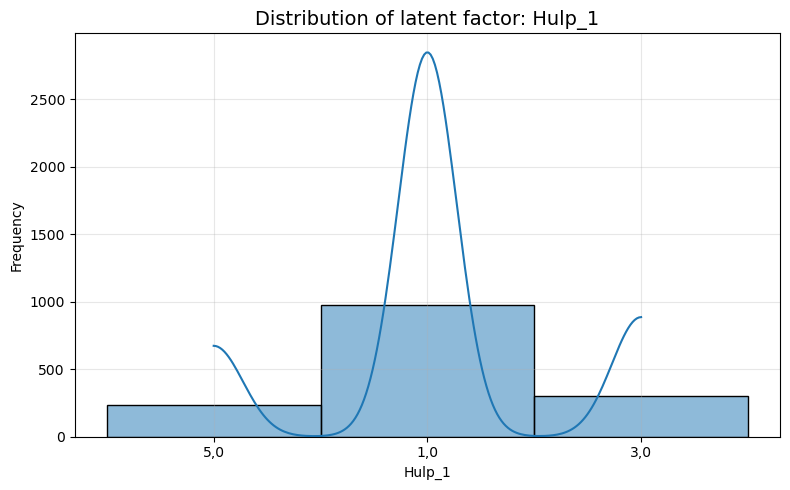

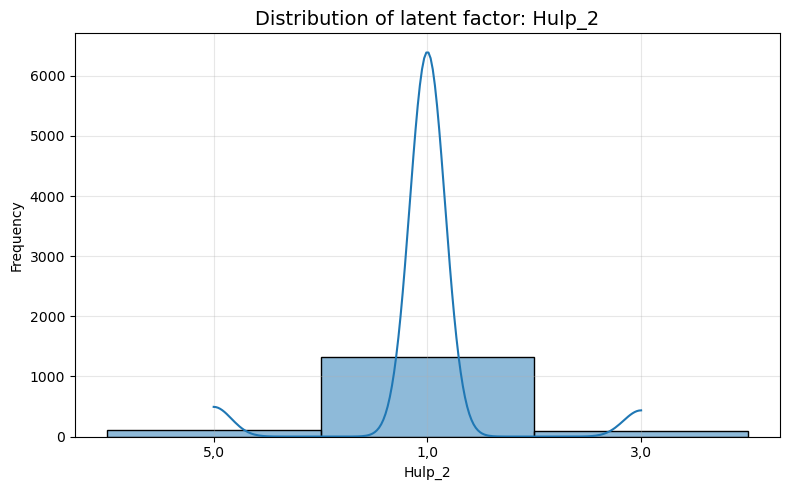

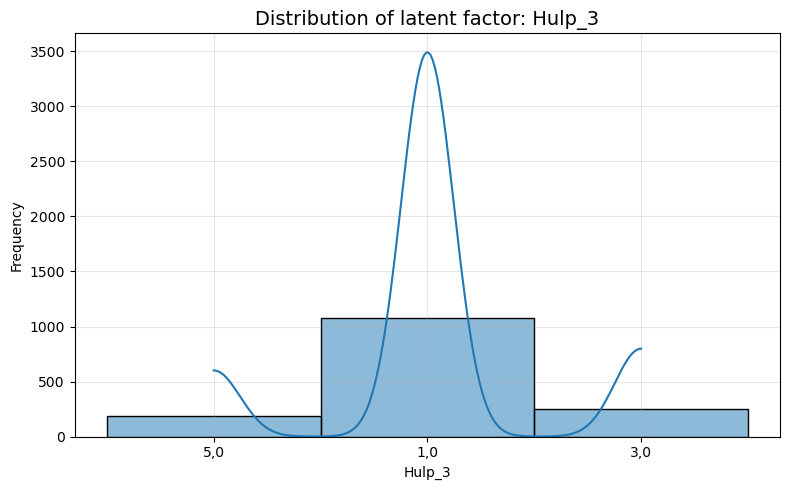

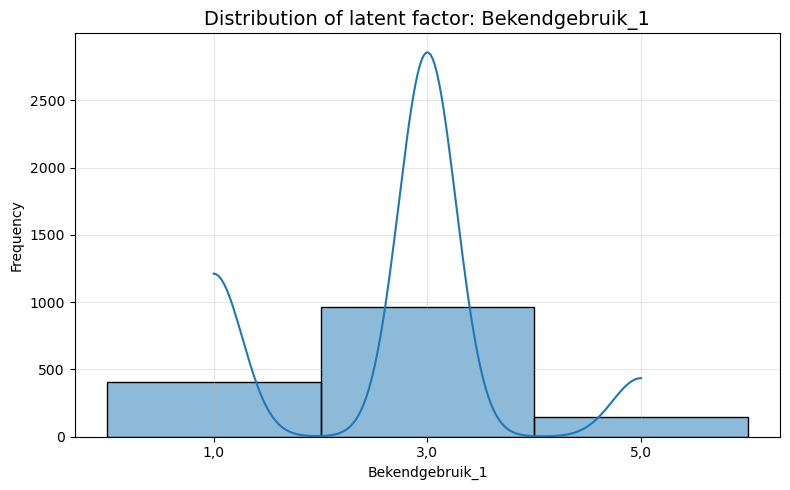

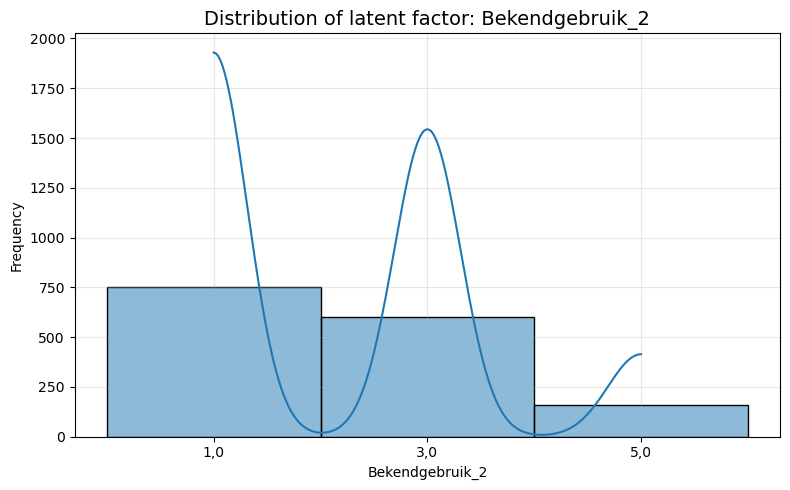

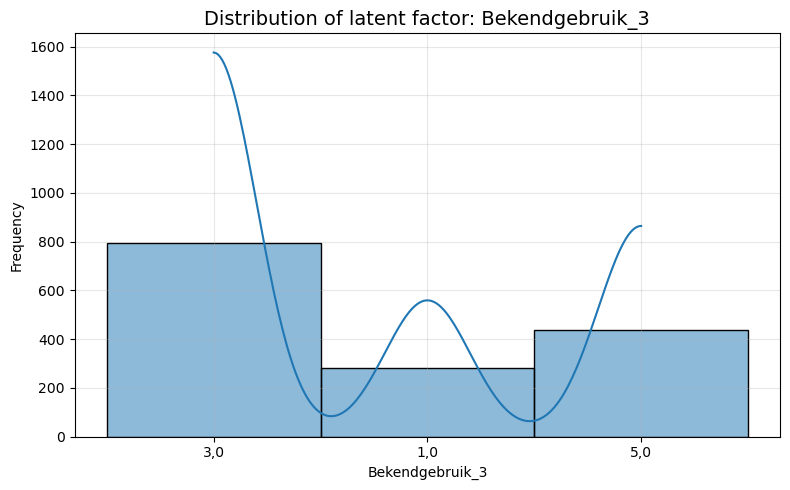

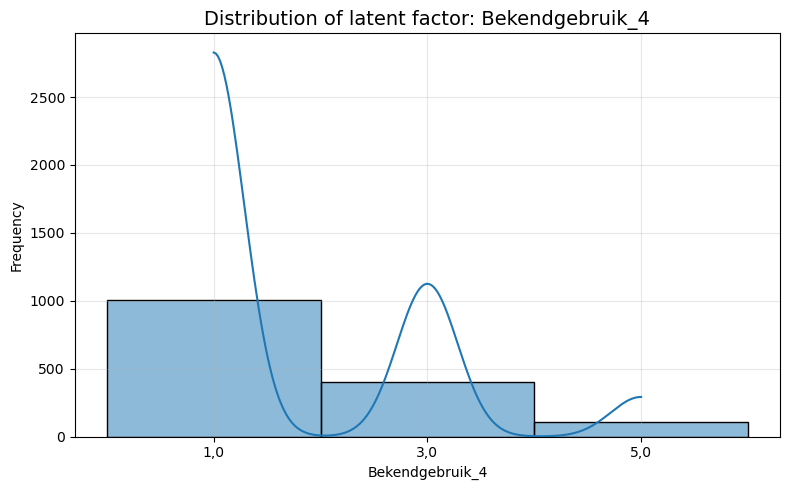

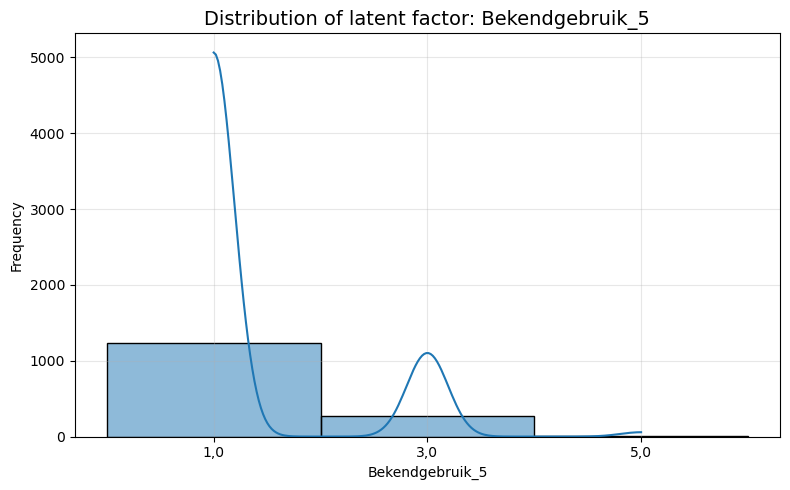

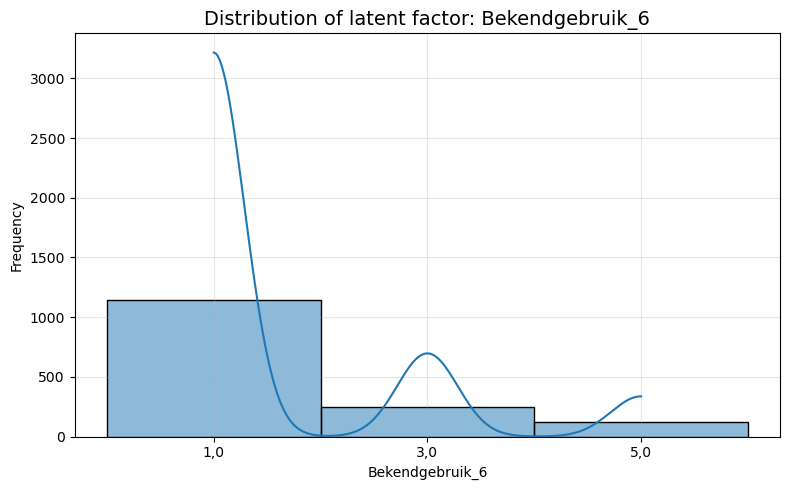

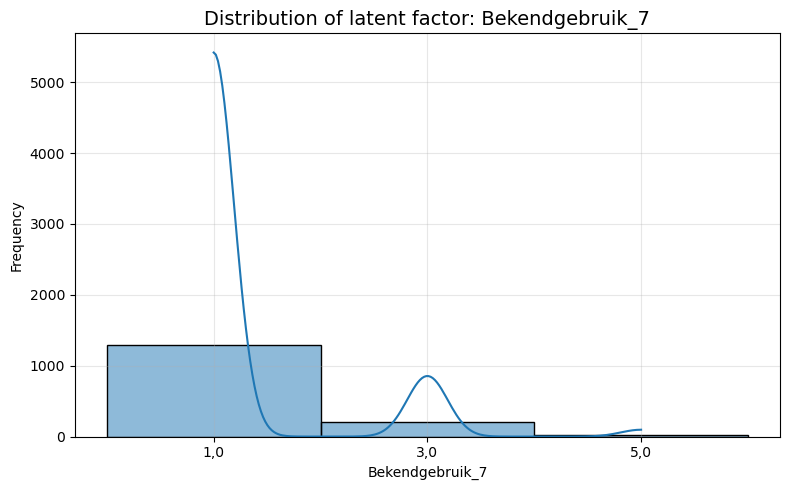

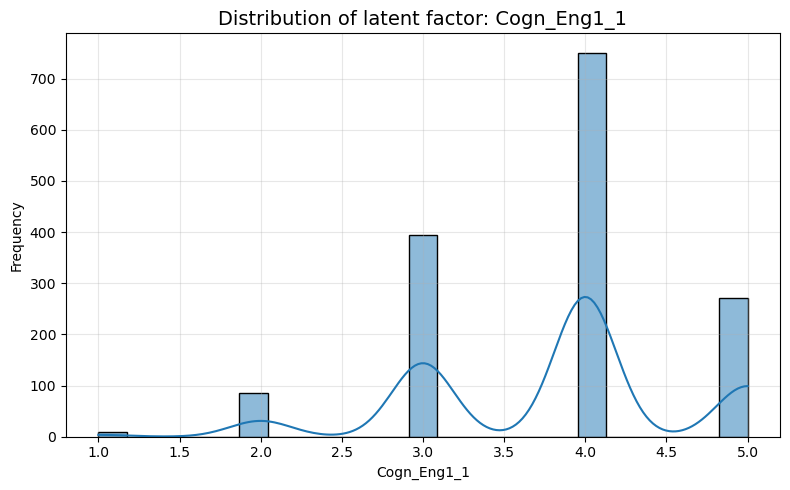

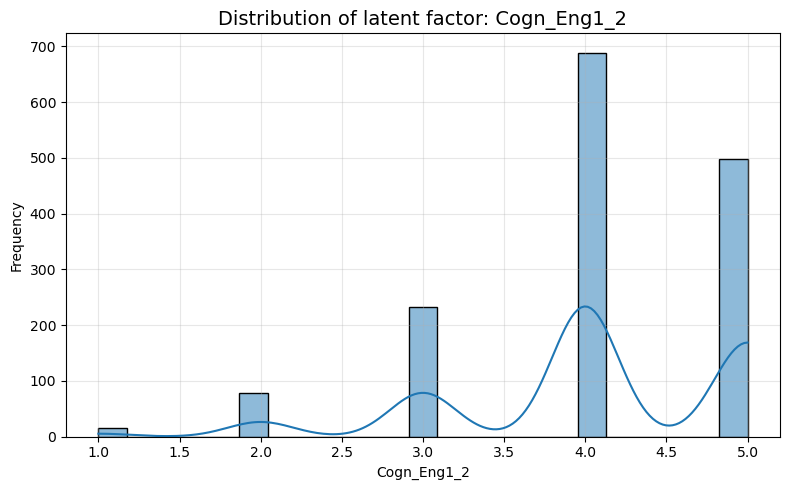

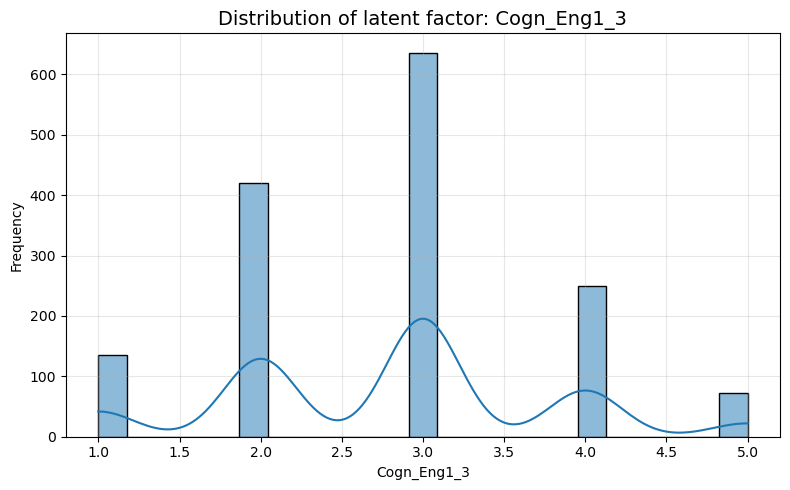

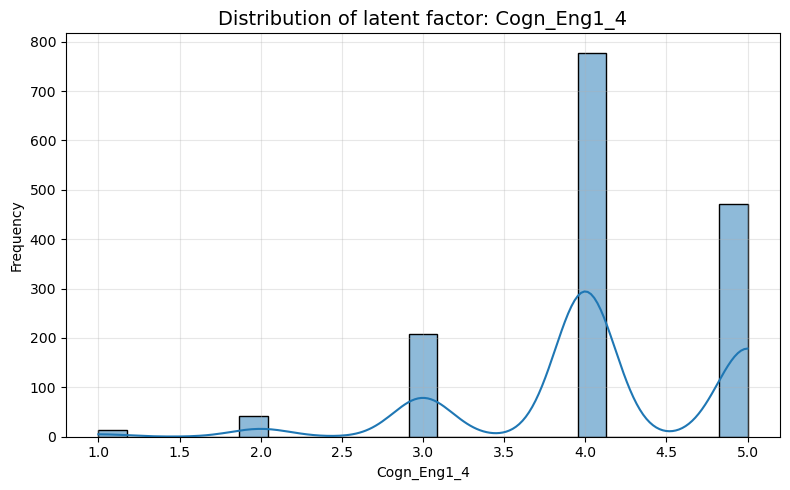

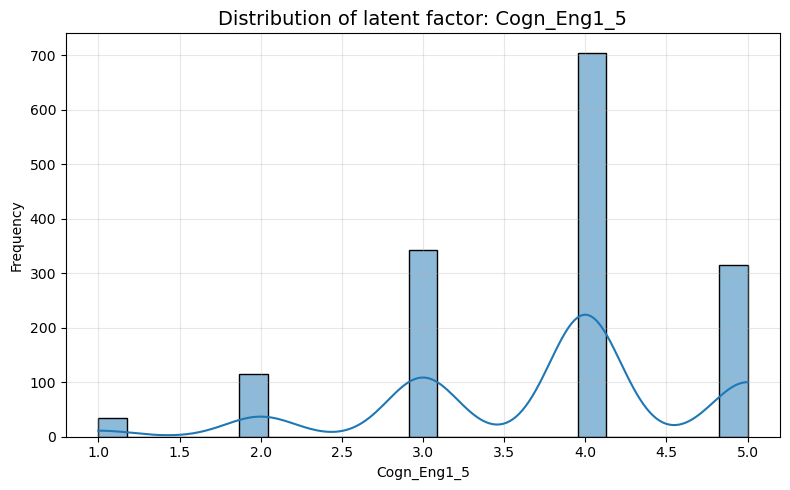

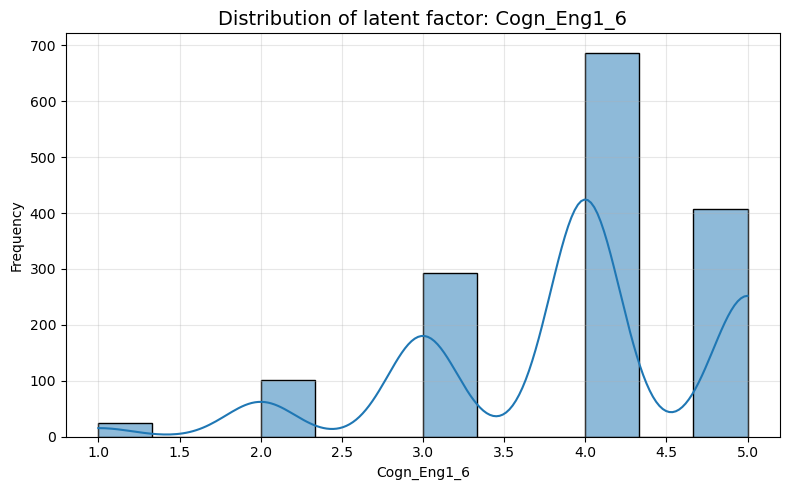

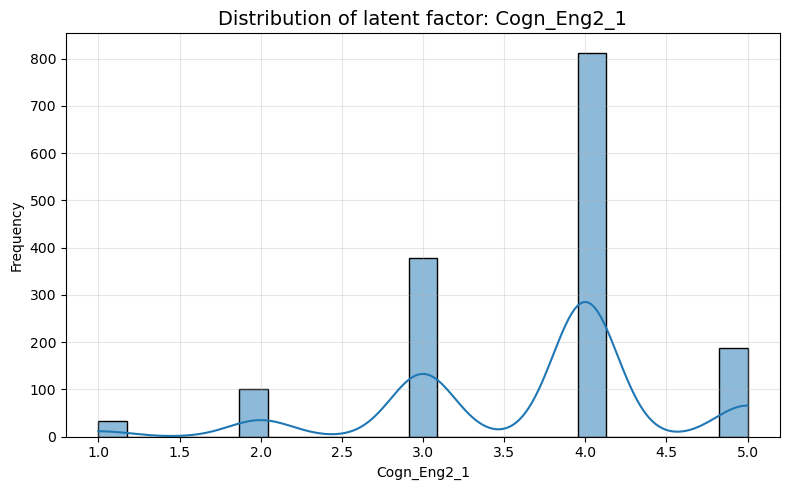

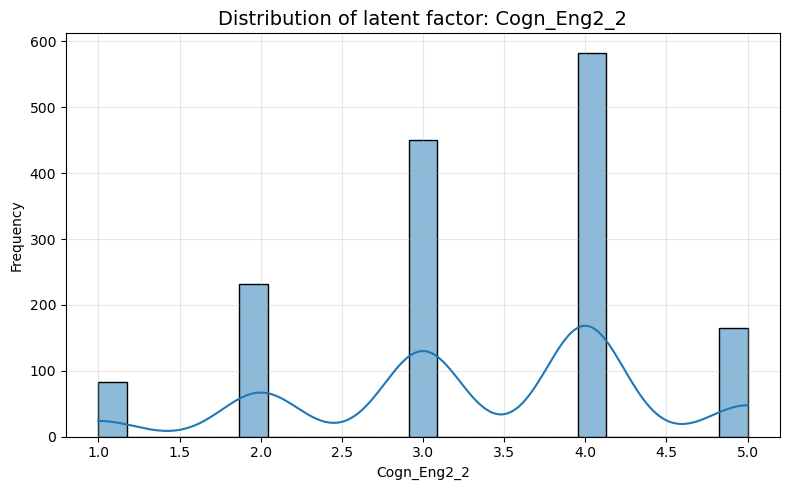

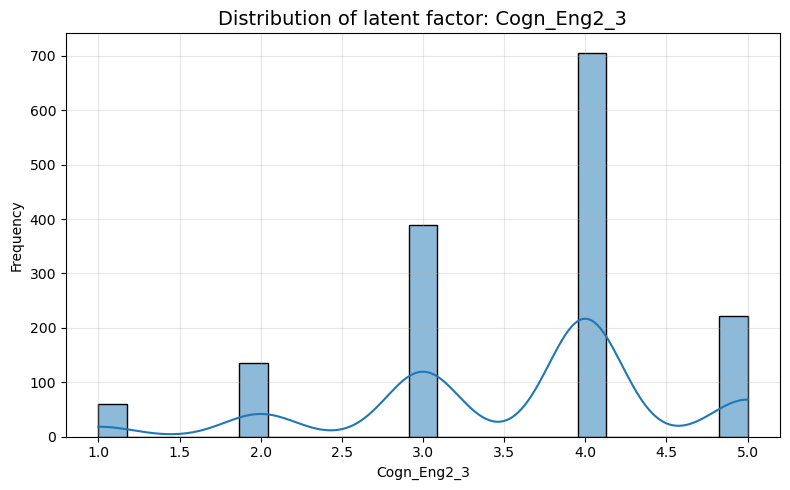

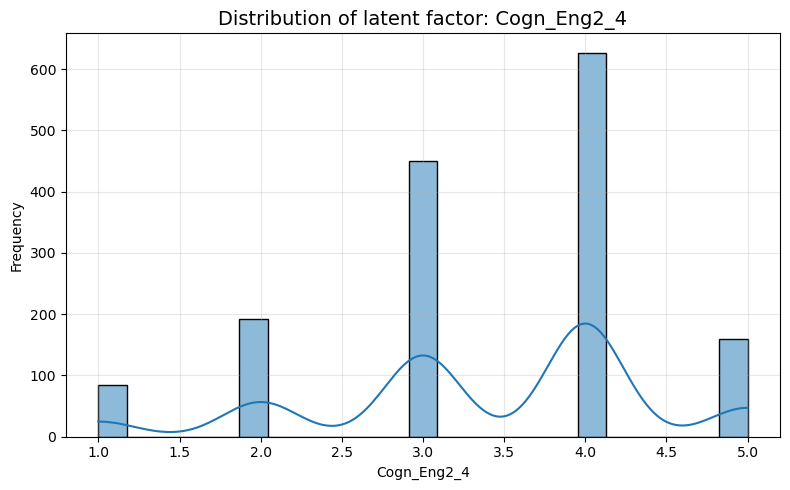

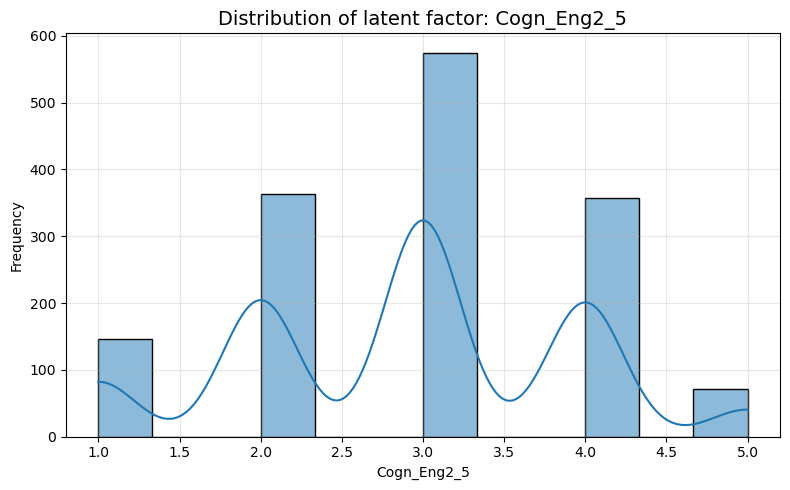

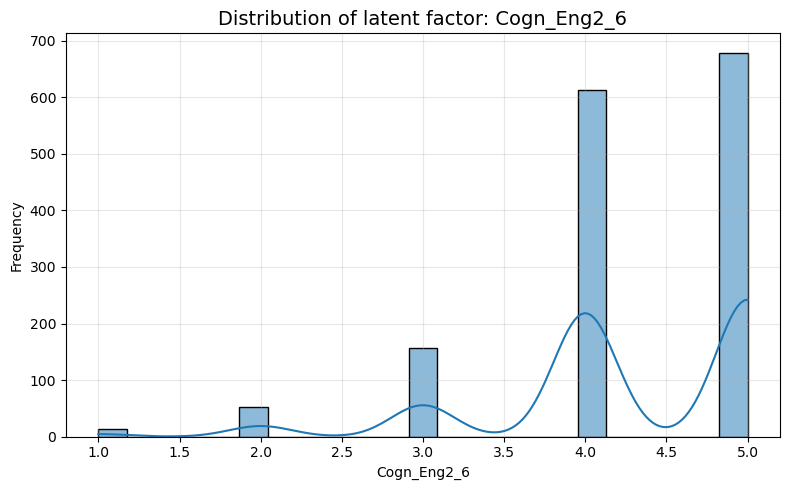

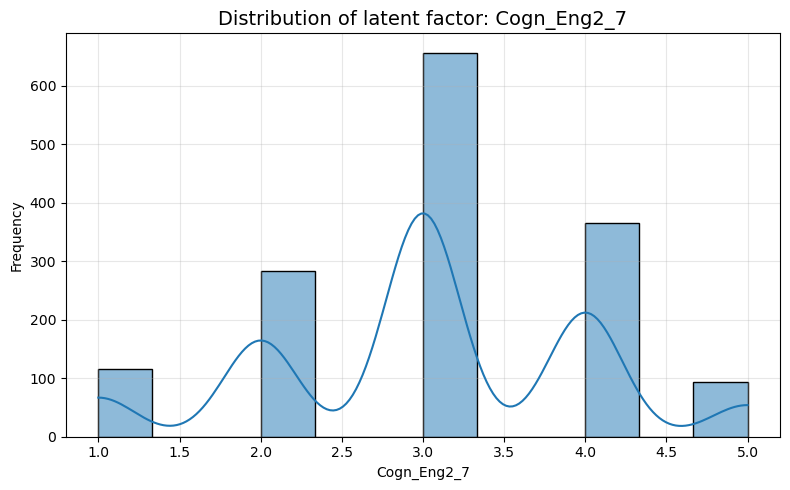

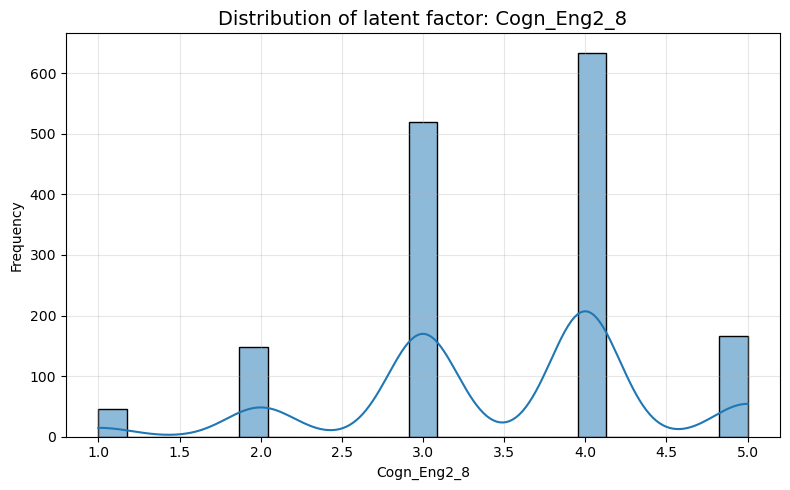

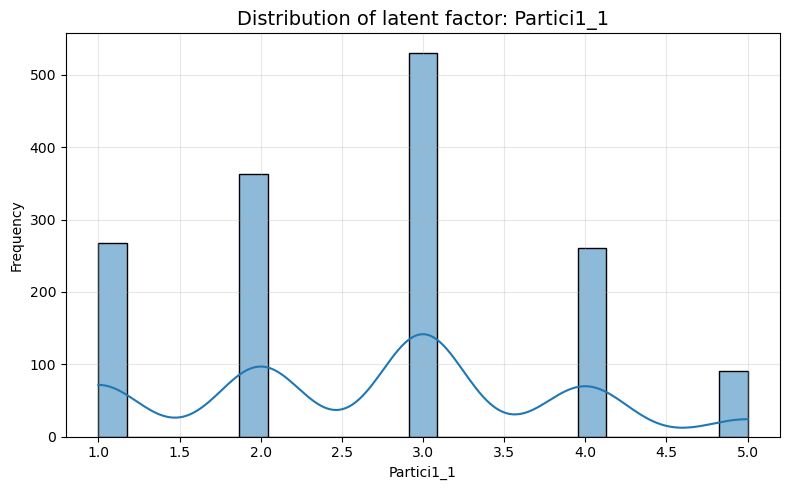

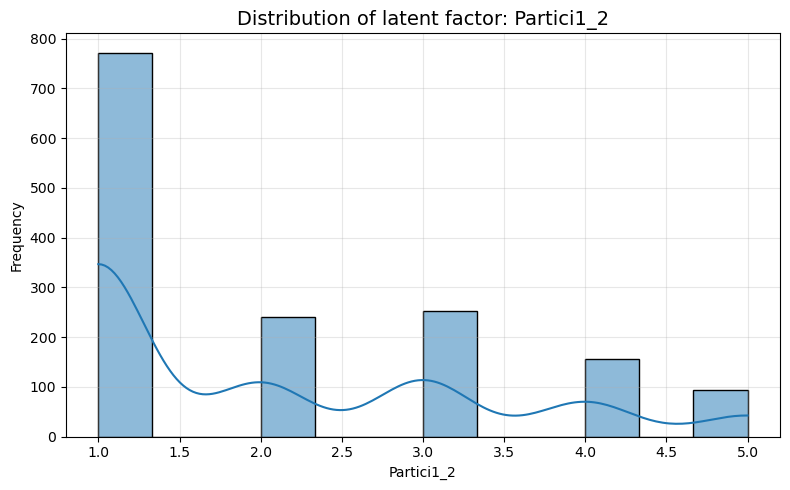

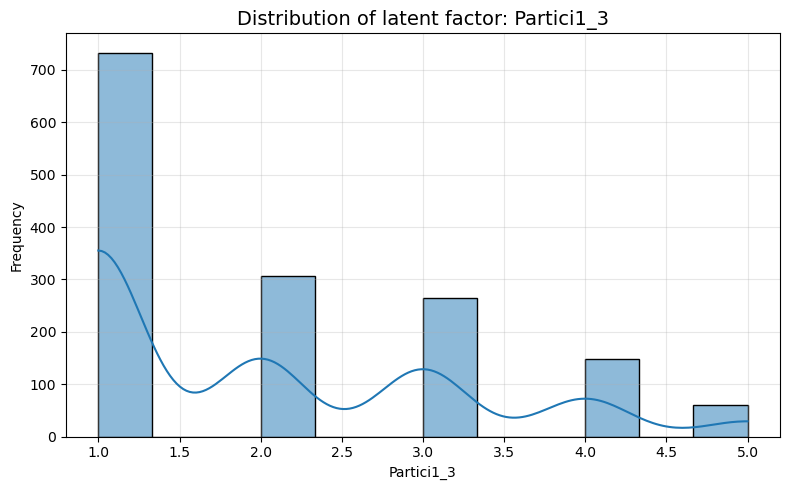

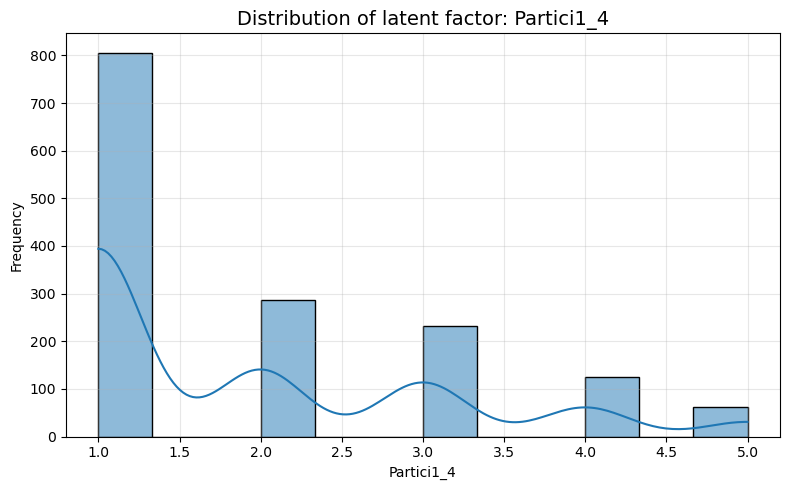

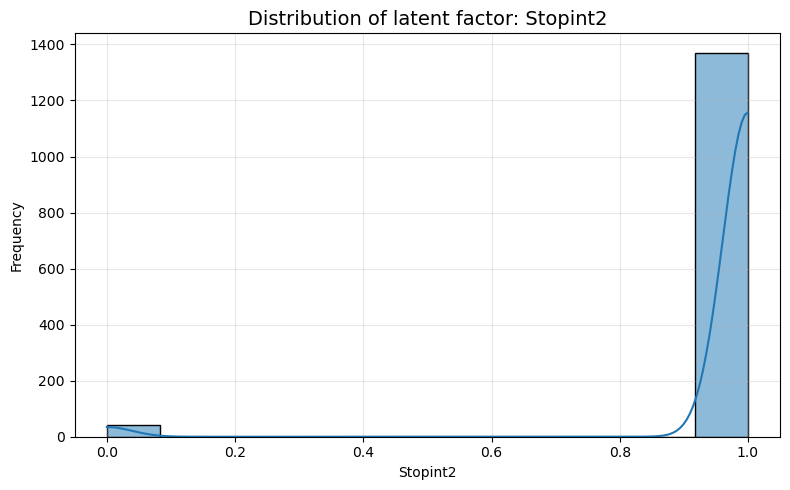

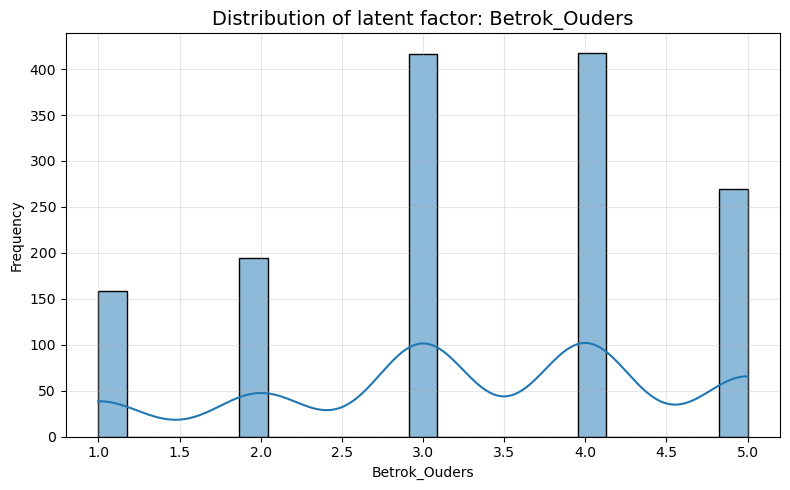

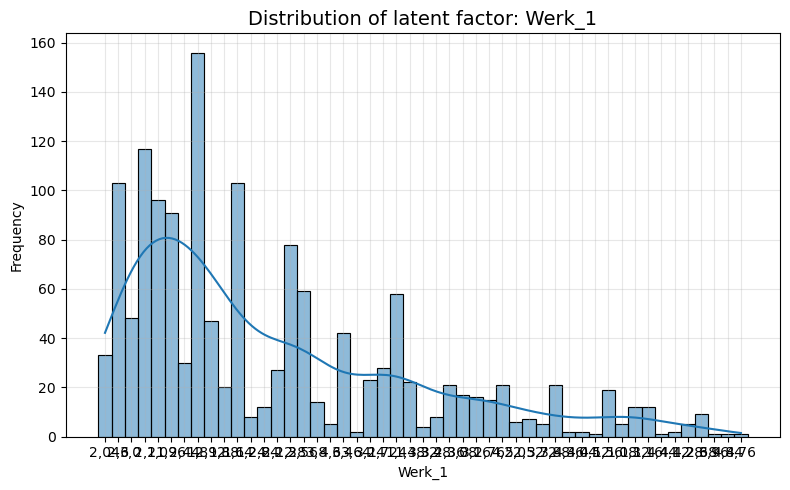

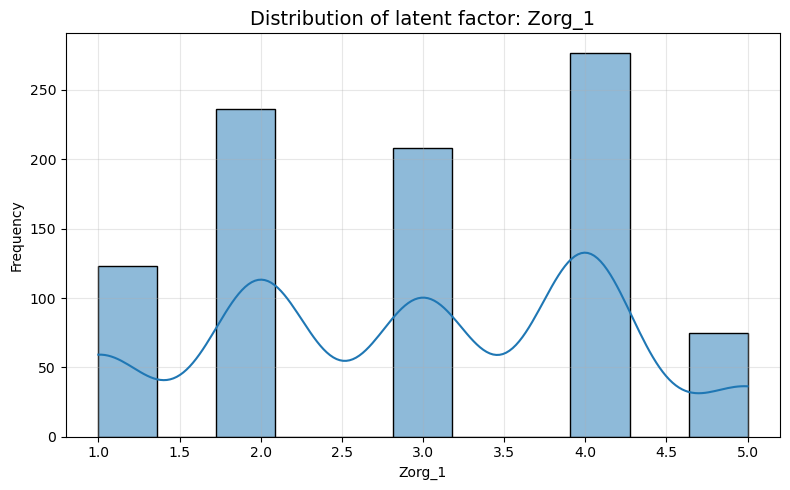

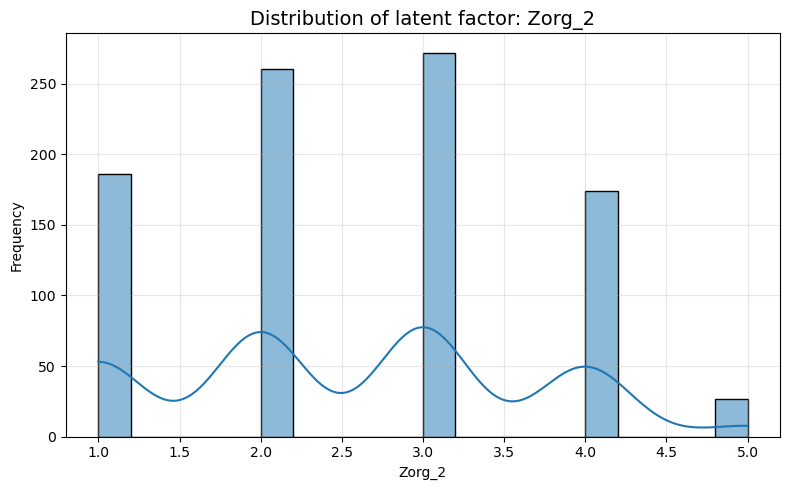

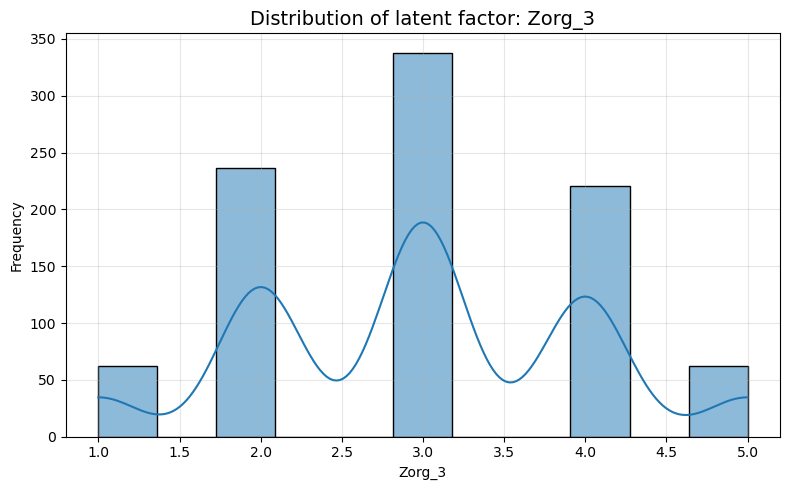

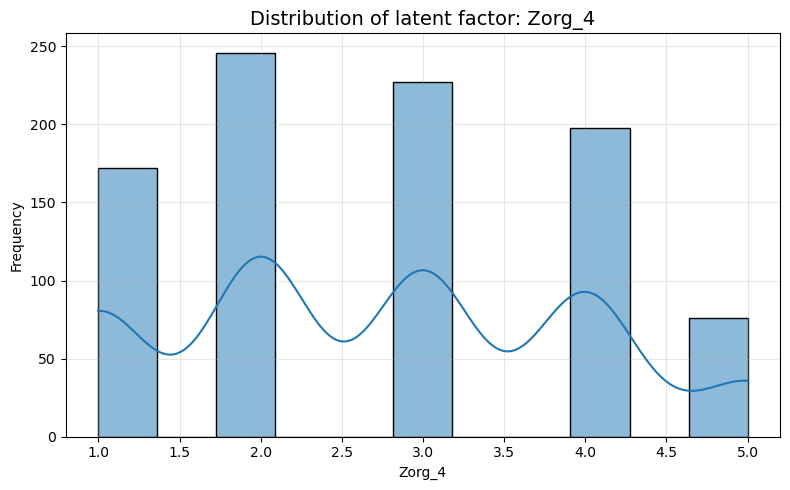

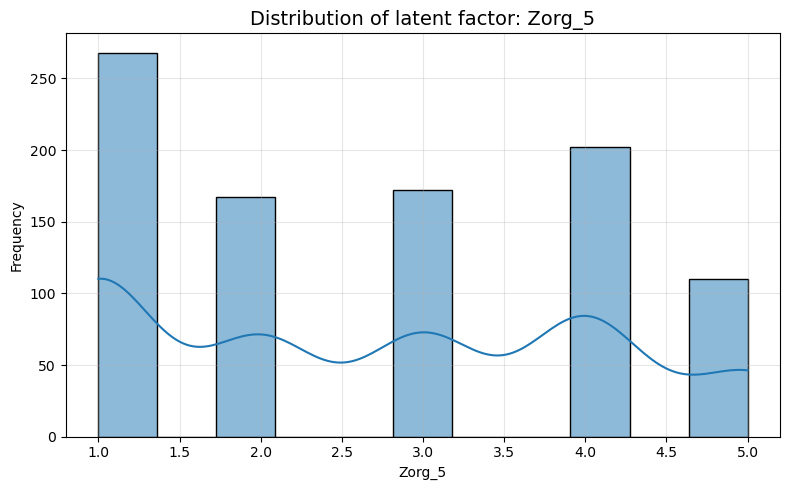

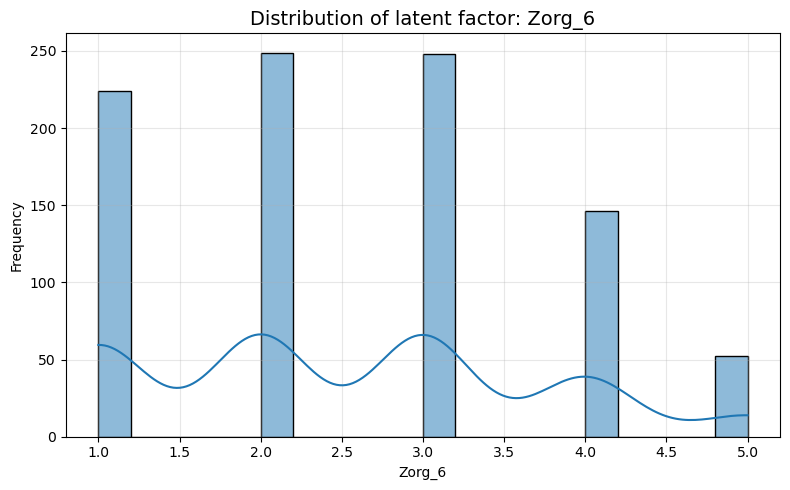

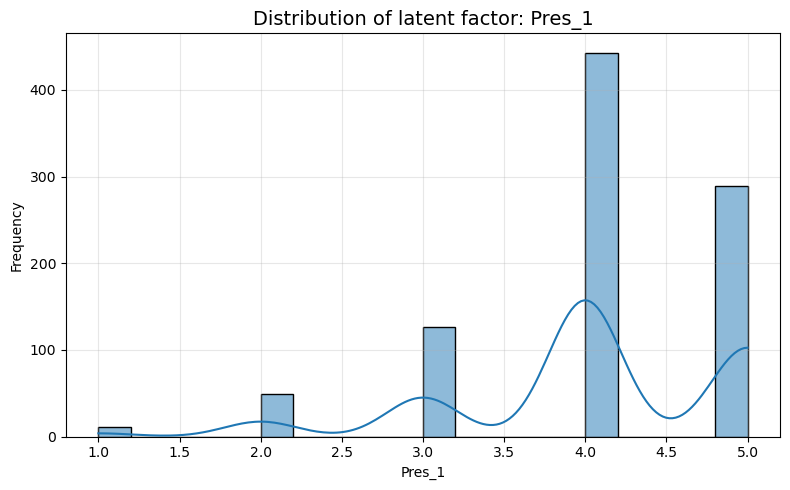

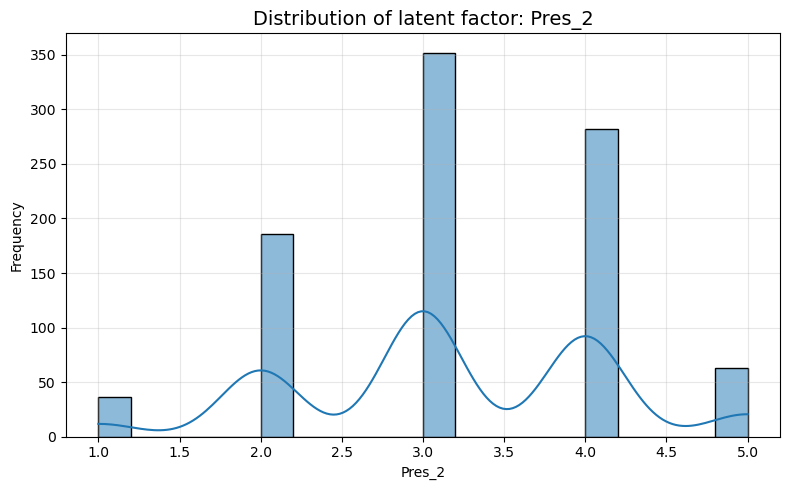

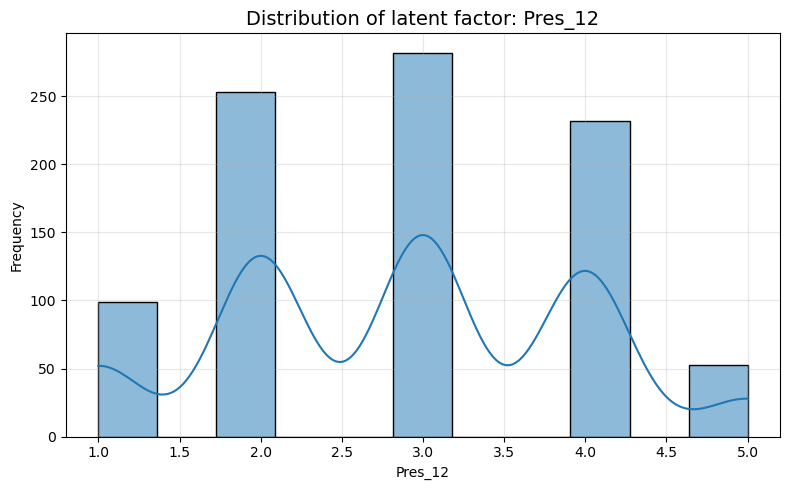

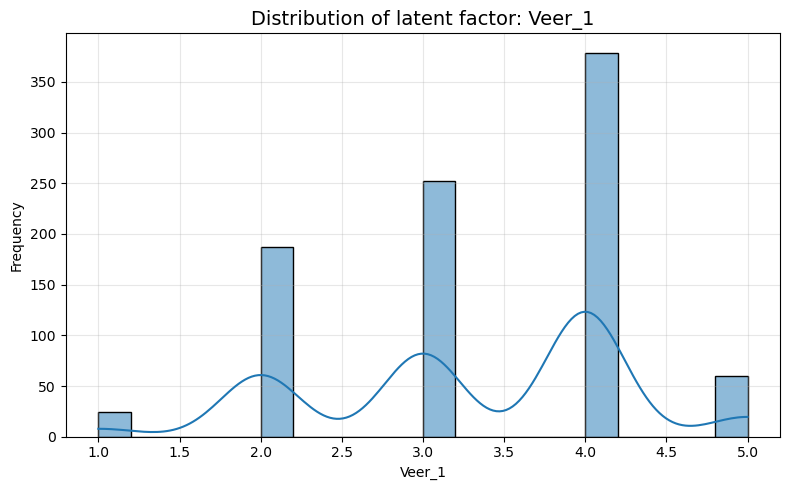

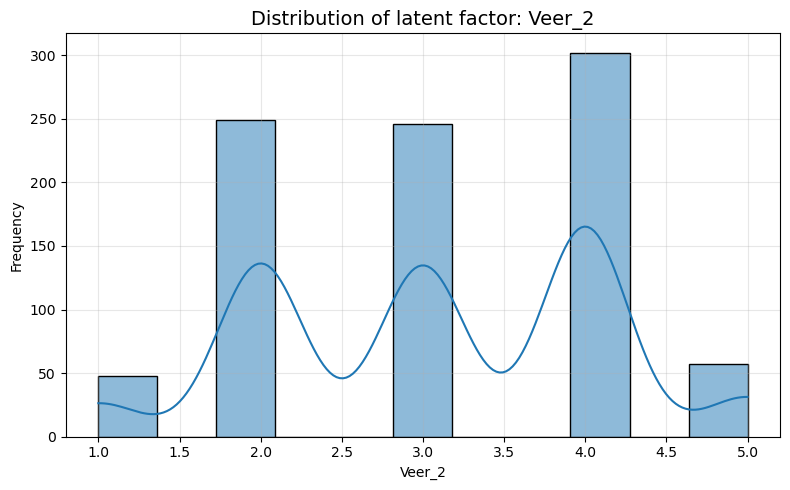

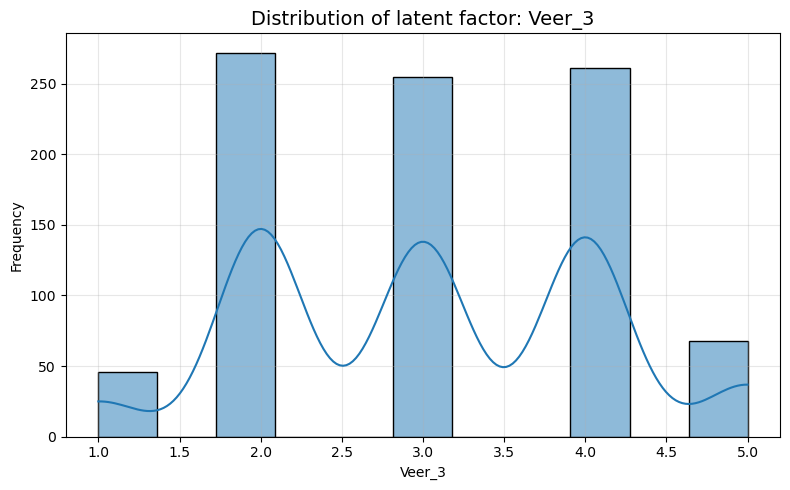

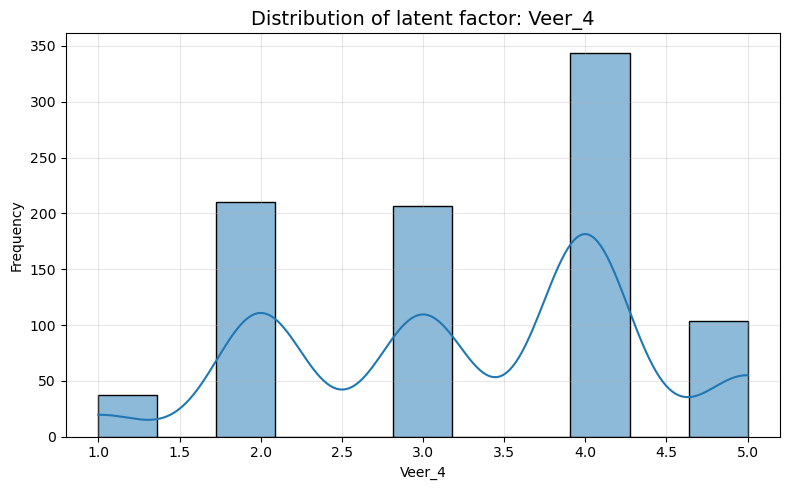

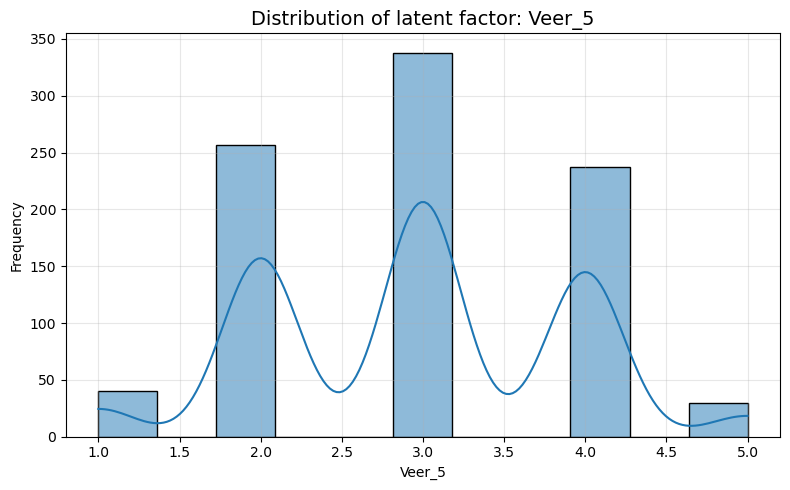

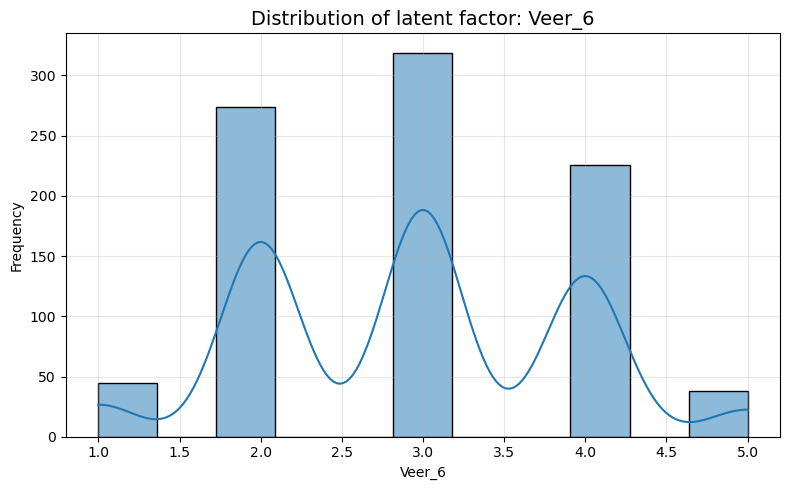

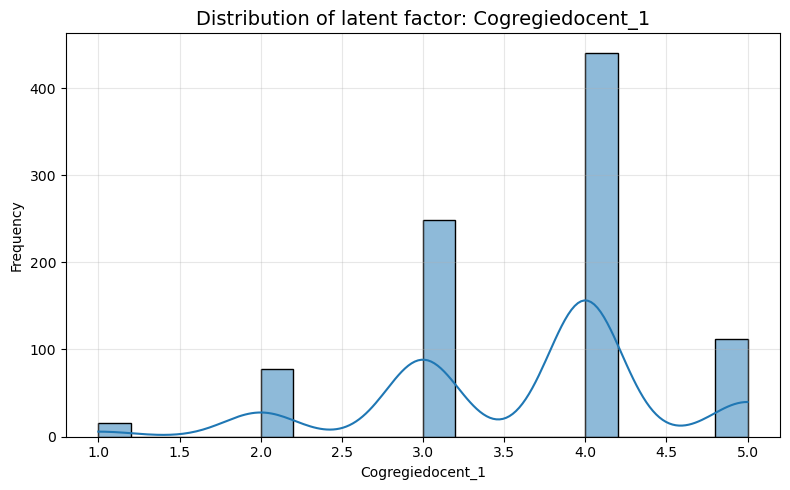

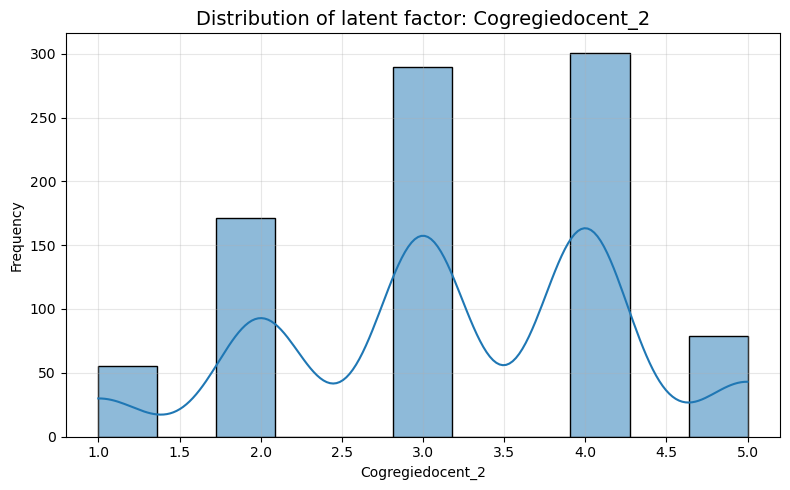

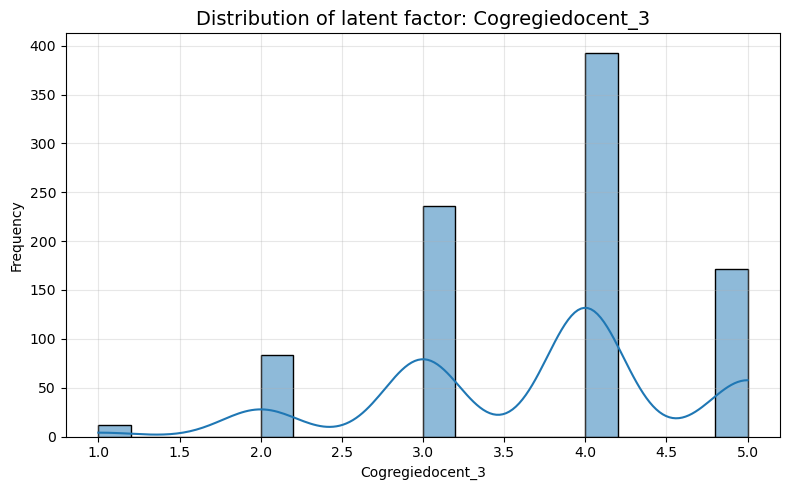

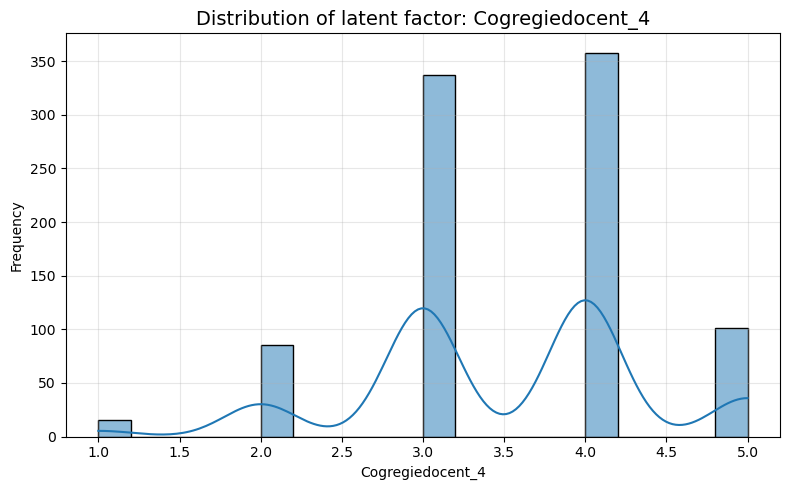

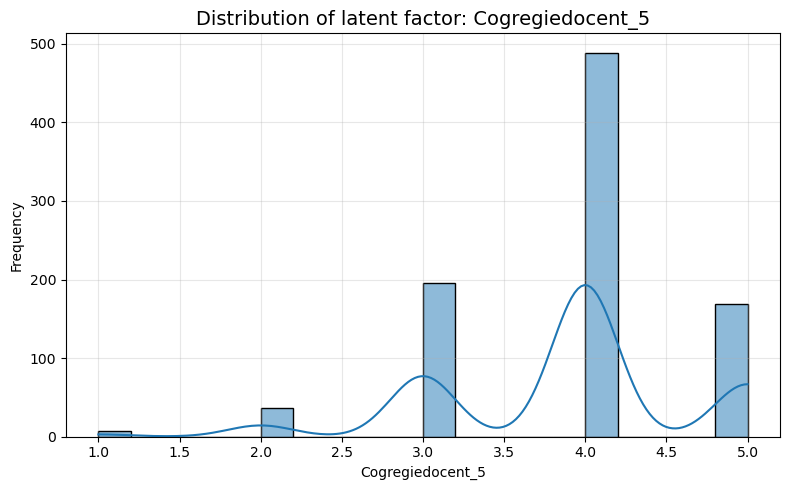

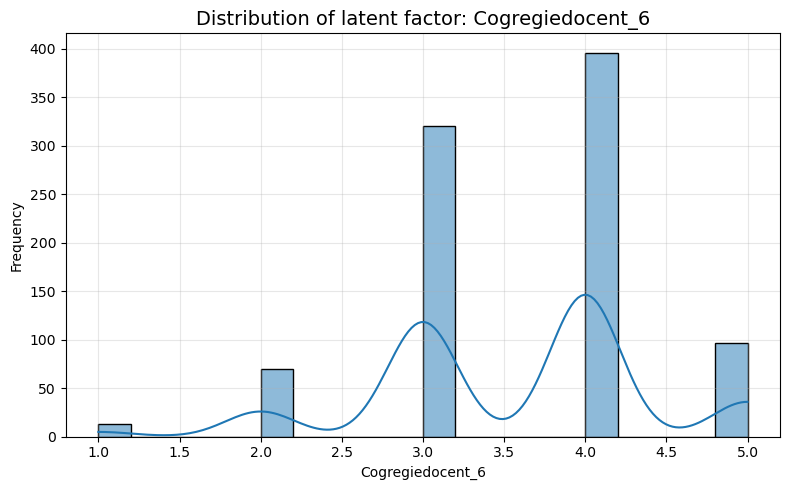

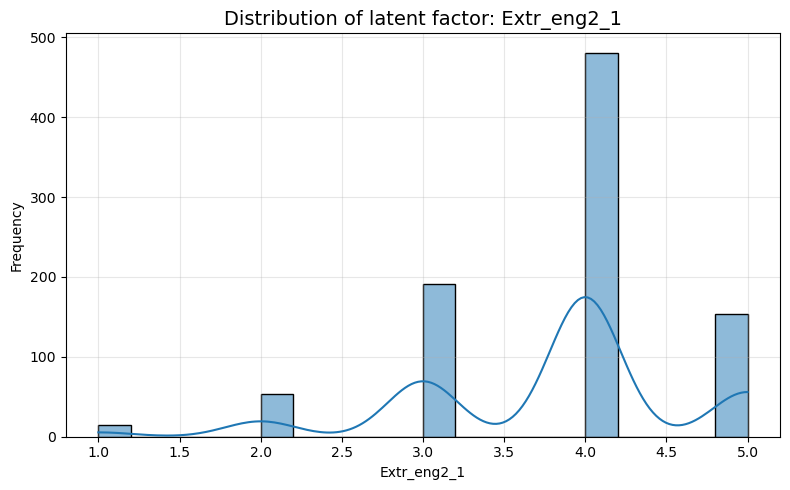

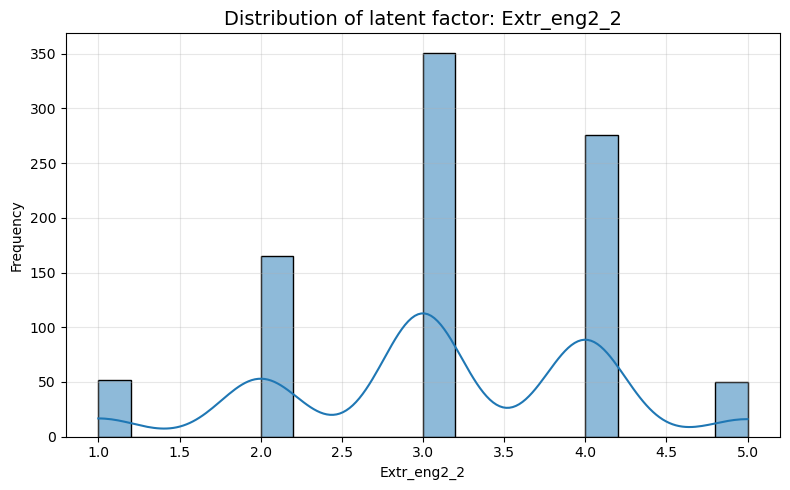

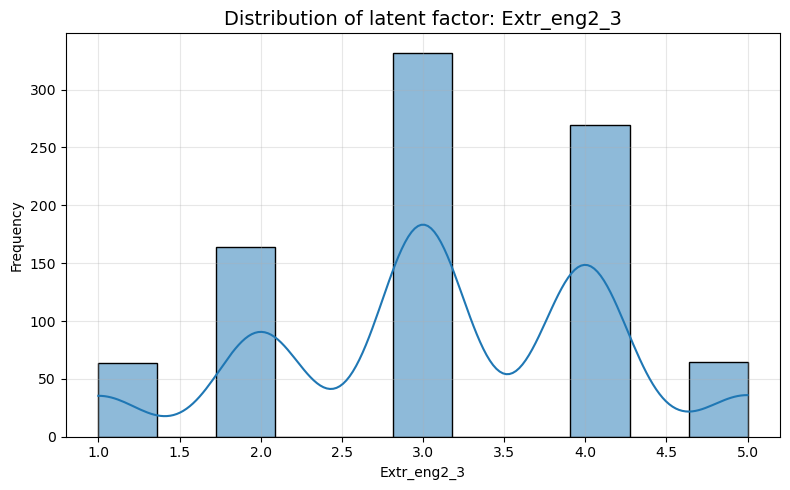

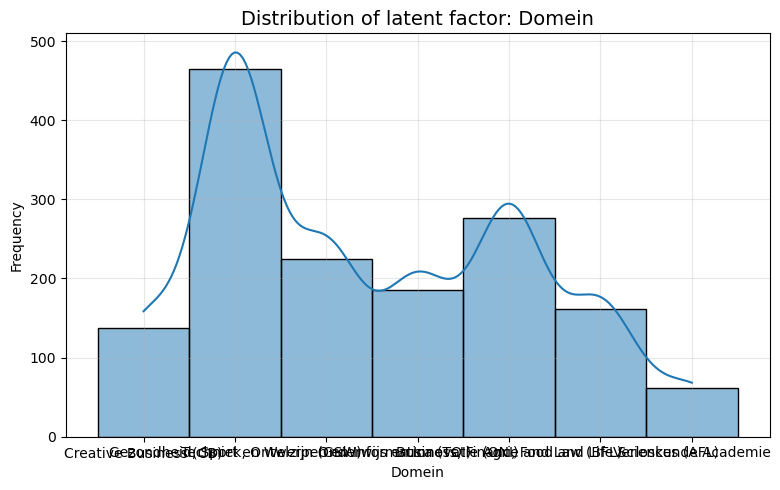

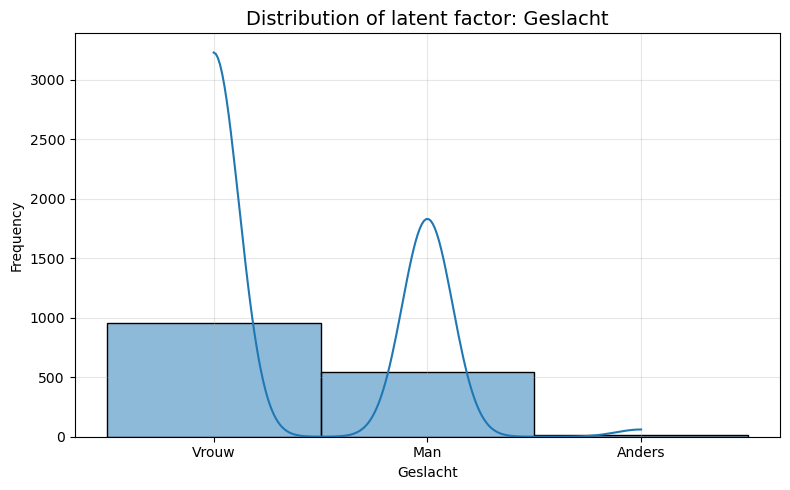

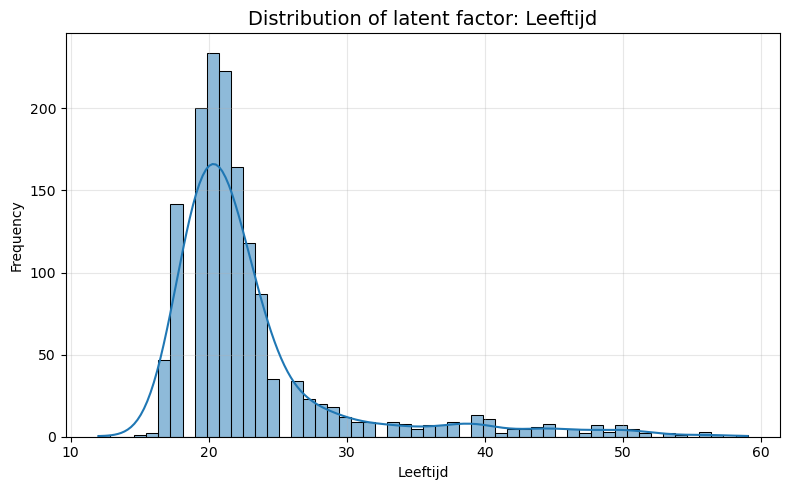

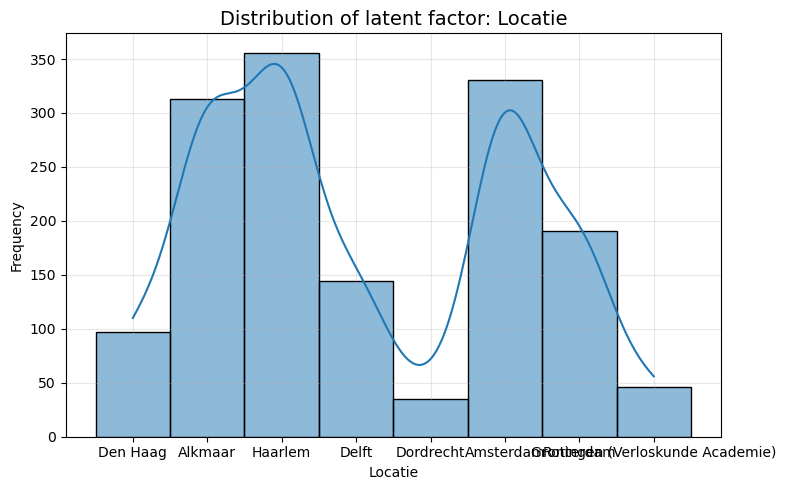

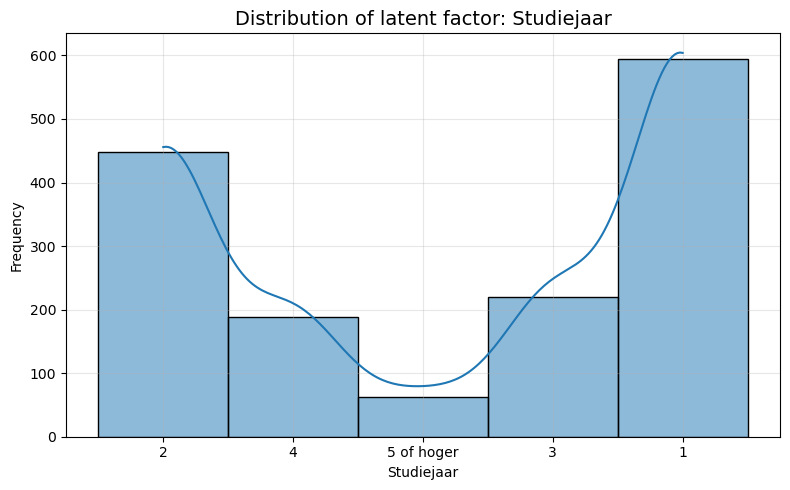

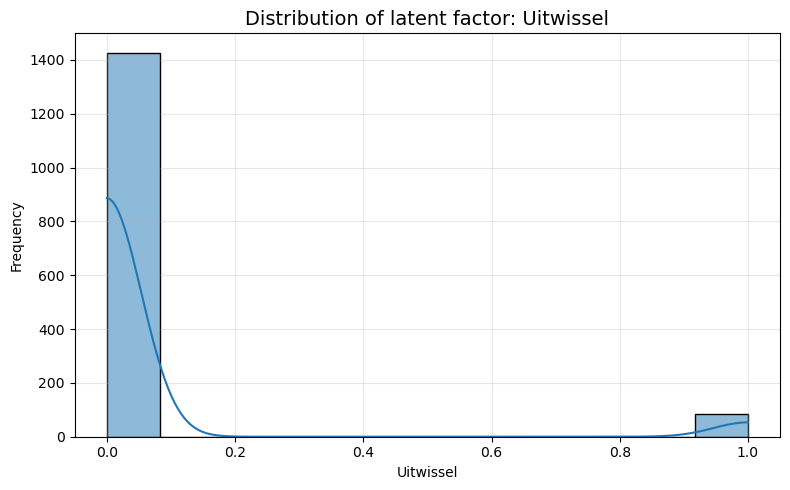

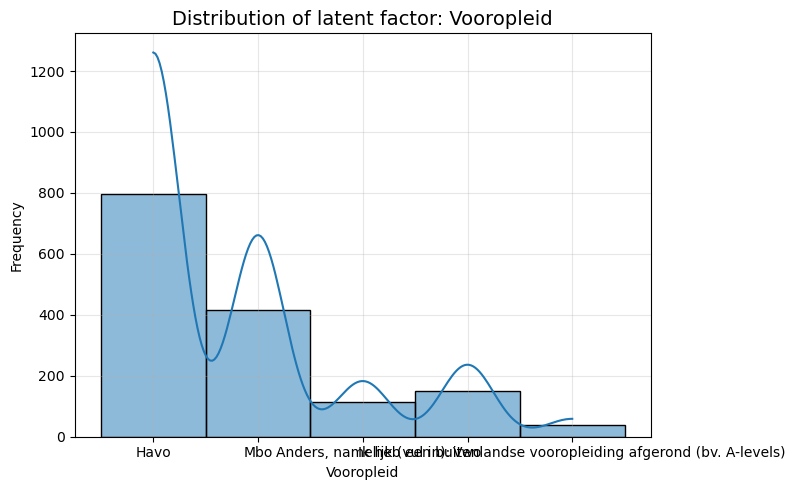

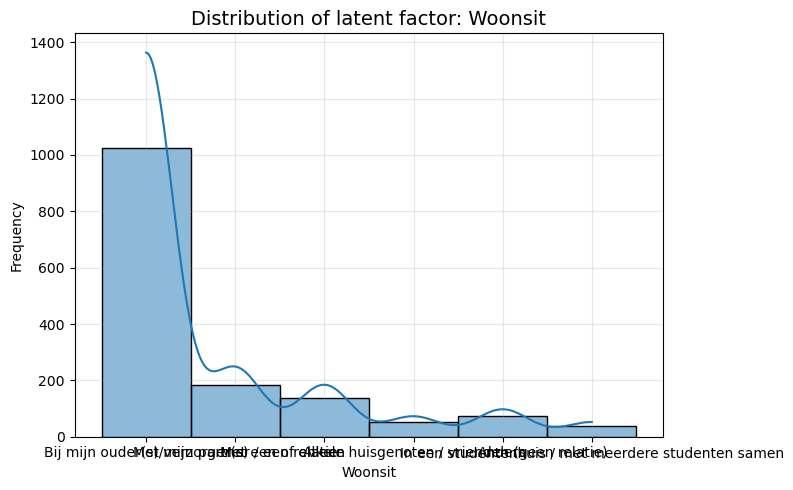

In [17]:
# Plot histogram for each latent variable
for col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of latent factor: {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Latent variables' descriptive statistics
Check for data type and create the SEM model

In [27]:
for col in df.columns:
        if df[col].dtype == "object":
            # replace comma decimals with dots
            df[col] = (
                df[col]
                .str.replace(",", ".", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
# df.dtypes

In [22]:
model_desc = """
# measurement model

Wellbeing =~ Bevl_1 + Bevl_2 + Bevl_3 + Cogn_Eng1_5 + Mot_Stress_1 + Mot_Stress_4
Energy_Sources =~ Partici1_1 + Partici1_2 + Partici1_3
Negative_Outcomes =~ StopInt + Vertr
Positive_Outcomes =~ Cijfer_huidig_1 + StPunt_beh
Stressors =~ Onnodige_stress_2 + Onnodige_stress_3 + Onnodige_stress_4 + Onnodige_stress_5 + Onnodige_stress_6 + Onnodige_stress_8 + Onnodige_stress_9
Response_to_Stress =~ Burn1_1 + Burn1_2 + Depr_1 + Depr_2 + Depr_4 + Depr_6 + Depr_7 + Depr_8

# Covariances (two-headed arrows in the diagram)
Response_to_Stress ~~ Wellbeing
Stressors ~~ Energy_Sources
Negative_Outcomes ~~ Positive_Outcomes

# Regressions
Response_to_Stress ~ Stressors + Energy_Sources
Wellbeing ~ Stressors + Energy_Sources

Negative_Outcomes ~ Response_to_Stress + Wellbeing
Positive_Outcomes ~ Wellbeing + Response_to_Stress
"""

Create the model and plot latent variable distributions

In [ ]:
model = Model(model_desc)
model.fit(df)

df_imputed = model.predict(df)
latent_scores = model.predict_factors(df_imputed)

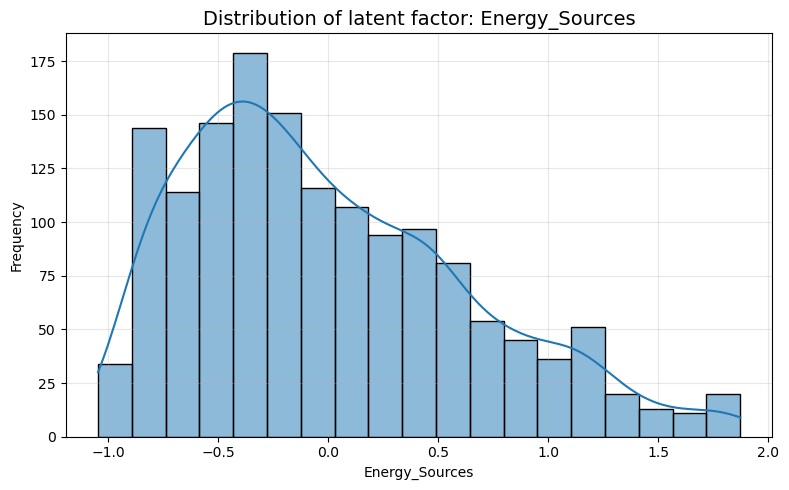

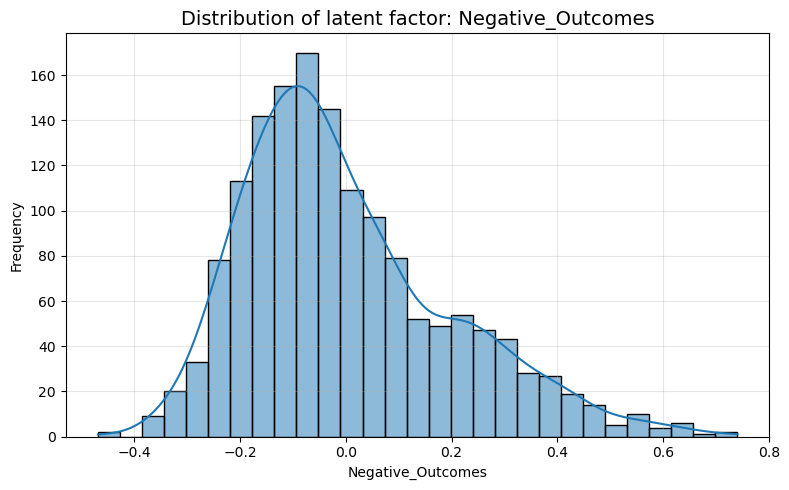

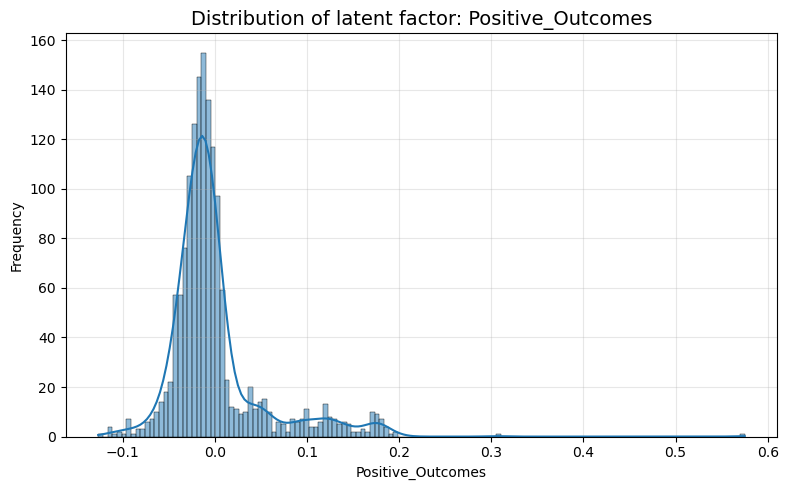

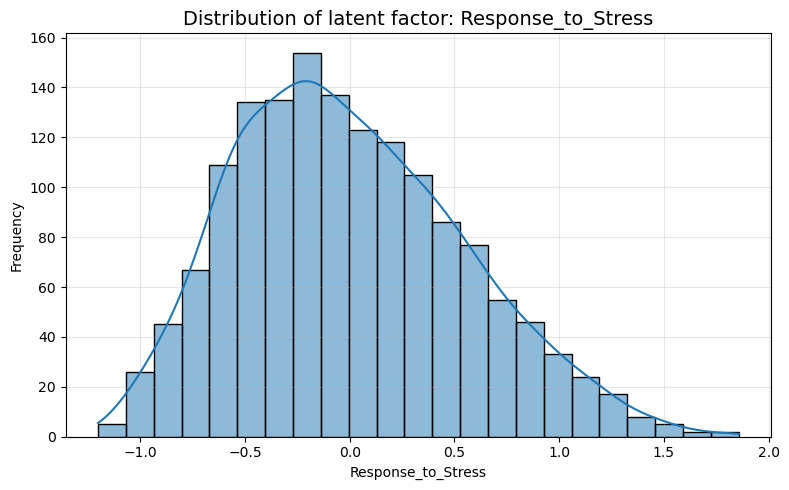

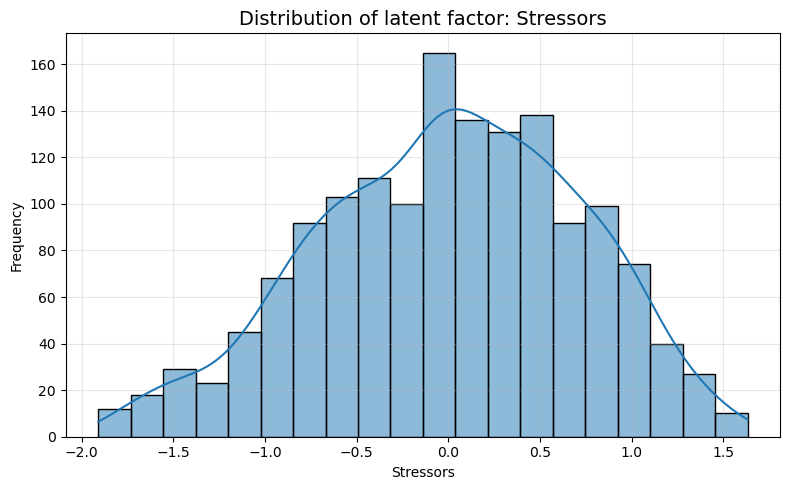

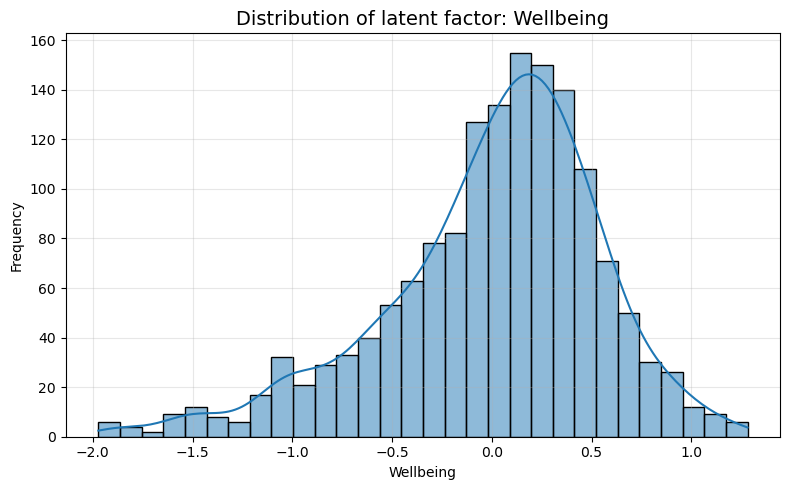

In [ ]:
# Plot histogram for each latent variable
for col in latent_scores.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(latent_scores[col], kde=True)
    plt.title(f"Distribution of latent factor: {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Create correlation matrix for the latent variables

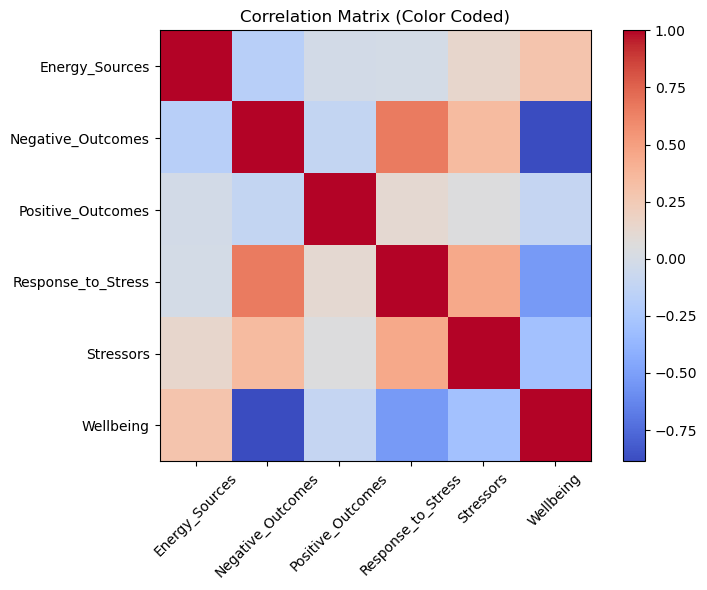

In [26]:
corr_matrix = latent_scores.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest', cmap='coolwarm')
plt.title("Correlation Matrix (Color Coded)")
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.tight_layout()
plt.show()